In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
import os
import pickle
import pandas as pd
import numpy as np
import h5py
import pingouin as pg
import tqdm
from tqdm import tnrange as trange

import seaborn as sns
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt

mpl.rcParams['svg.fonttype'] = 'none'
sns.set_context('poster', font_scale=1.1)
cmap = plt.rcParams['axes.prop_cycle'].by_key()['color']

import scipy
from scipy import signal
from scipy.signal import butter, filtfilt,freqz, find_peaks, resample,lfilter
from scipy.stats import norm,entropy,linregress, ttest_rel
from scipy.optimize import minimize, curve_fit
from scipy.io import savemat
from scipy.special import erf

#modulename = 'multiprocess'
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, permutation_test_score, StratifiedKFold, GroupKFold
from sklearn.cluster import AffinityPropagation, DBSCAN
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from functions_beh import*
from odor_breathing_functions import*

def cell_compiler(cell_list):

    ncells = len(cell_list)
    ntrials = len(cell_list[0]['spike_times'])
    counts = 1000
    test_cell = np.zeros((ncells, ntrials,counts)) 

    for i in range(ncells):
        cellid = cell_list[i]
        for trial in range(ntrials):

            if isinstance(cellid['spike_times'][trial], np.ndarray):  # Check if the item is a NumPy array
                if cellid['spike_times'][trial].size == 0:  # Check if the array is empty
                    trial_spikes = 0
                    #print("This subarray is empty")
                elif cellid['spike_times'][trial].size == 1:  # Check if the array contains a single element
                    #print(f"This is a single-element array: {cellid['spike_times'][trial]}")
                    test_cell[i,trial,0] = cellid['spike_times'][trial]
                else:
                    trial_spikes = cellid['spike_times'][trial]
                    for spk in range(len(trial_spikes)):
                        test_cell[i,trial,spk] = trial_spikes[spk]


    test_cell[test_cell==0] = np.nan
    return test_cell

def firing_rates_compiler(cell_list):

    ncells = len(cell_list)
    ntrials = len(cell_list[0]['spike_times'])
    counts = 450
    test_fr_cell = np.zeros((ncells, ntrials,counts)) 

    for i in range(ncells):
        cellid = cell_list[i]
        for trial in range(ntrials):
            test_fr_cell[i, trial,:] = cellid['firing_rate'][trial]

    #test_cell[test_cell==0] = np.nan
    return test_fr_cell

def code_compiler(data_list, cell_list):

    ncells = len(cell_list)
    ntrials = len(cell_list[0]['spike_times'])
    bins = 100
    test_cell = np.zeros((ncells, ntrials,bins)) 

    for i in range(ncells):
        test_cell[i,:,:] = data_list['x_est_'+str(i)]
   
    return test_cell

In [2]:
#Flexible loop for compiling ephys data in a data frame. 

new_path = os.getcwd() + '/Bahareh/'
good_neurons_dic = pickle.load(open(new_path+"good_cells_BST.pickle", "rb",))
datax = str('_data_all.npy')

animal_list = [['Tabby'],['Shorthair'],['Bengal']]
session_id = 0
n_bins = 5 
results_list=list()

#filenames_to_delete = ['Tabby_20190512_0', 'Shorthair_20190502_0', 'Bengal_20190430_0']
    
for animals in animal_list:
    fname_list = list()
    for date_number in range(20190419,20190600):
        date_string = str(date_number)
        for animal in animals:
            fname = animal + '_' + date_string + '_' + str(session_id)+ '.pickle'
            #print(fname)
            cell_fname = new_path + 'cell_' + fname
            session_fname = new_path + 'session_' + fname
            if os.path.isfile(cell_fname) and os.path.isfile(session_fname):
                fname_list.append(fname[:-7])
            
    # for string in filenames_to_delete:
    #     if string in fname_list:
    #         fname_list.remove(string)

    sorted_fname_list = sorted(fname_list, reverse=False)
    list_of_sessions = len(sorted_fname_list)
    
    for i_session in range(list_of_sessions):

        animal_name = sorted_fname_list[i_session]
        print('session name', animal_name)
        session_fname = 'session_' + animal_name + '.pickle'
        cell_fname = 'cell_' + animal_name + '.pickle'
        good_cells = good_neurons_dic[animal_name]
        dat = np.load(new_path+animal_name+datax, allow_pickle=True)
        data = dat.tolist()
         
        session = pickle.load(open(new_path+session_fname,'rb'))[0]
        cell_list = pickle.load(open(new_path+cell_fname,'rb'))
        compiled_cells = cell_compiler(cell_list)
        compiled_fr = firing_rates_compiler(cell_list)
        #compiled_codes = code_compiler(data, cell_list)

        num_trials = min(session['num_trials'], cell_list[0]['num_trials'] )
        non_idle_trials = np.invert(session['idle_trials'])[:num_trials]
        correct_trials = session['correct_trials'][:num_trials][non_idle_trials]
        high_trials = session['high_trials'][:num_trials][non_idle_trials]
        low_trials = session['low_trials'][:num_trials][non_idle_trials]
        trial_odor = session['trial_odor'][:num_trials][non_idle_trials][0:5000]
        high_choices = (correct_trials==high_trials)
        breathing_signal = np.append(session['trial_pre_breath'][:num_trials][non_idle_trials, -2500:],
                                     session['trial_breath'][:num_trials][non_idle_trials, :6500], axis=1)
        
        cum_odor = np.ceil(trial_odor.sum(axis=1)/5000)
        non_idle_cell_data = compiled_cells[:,non_idle_trials,:]
        non_idle_cell_fr = compiled_fr[:,non_idle_trials,:]

        #non_idle_codes = compiled_codes[:,non_idle_trials,:]
        sniff_hist = get_sniff_histogram(session,False)[:num_trials][non_idle_trials]
        
        high_seven = cum_odor>8
        low_eight = cum_odor<=8
        bad_trials_1 = np.logical_and(high_seven,low_trials)
        bad_trials_2 = np.logical_and(low_eight,high_trials)
        bad_trials = np.logical_or(bad_trials_1,bad_trials_2)
        good_trials = np.invert(bad_trials)
        all_correct_trials = correct_trials[good_trials]
        all_high_trials = high_trials[good_trials]
        all_low_trials = low_trials[good_trials]
        all_high_choices = high_choices[good_trials]
        all_cum_odor = cum_odor[good_trials]
        all_trial_odor = trial_odor[good_trials,:]
        all_breathing = breathing_signal[good_trials,:]
        all_sniff_hist = sniff_hist[good_trials,:]
        all_cell_data = non_idle_cell_data[:,good_trials,:]
        all_fr_data = non_idle_cell_fr[:,good_trials,:]
        # all_codes_data = non_idle_codes[:,good_trials,:]
        # all_codes_data[all_codes_data == 0] = np.nan
        
        num_cells = len(good_cells) #kernel.shape[0]
        for trial in range(len(all_correct_trials)):
            for cell in range(num_cells):
                cell_id = good_cells[cell]
                spikes_list = []
                for value in all_cell_data[cell_id,trial,:]:
                    if not np.isnan(value):
                        spikes_list.append((int(value)+15000)/30000) 

                result_row_1 = {'Animal': animals[0],
                'Session': animal_name,
                'Date': animal_name[-10:-2],
                'Trial': trial,
                'Total_pulse': all_cum_odor[trial].astype(int),
                'High_trial': all_high_trials[trial].astype(int),
                'High_choice': all_high_choices[trial].astype(int),
                'Correct': all_correct_trials[trial].astype(int),
                'Trial odor': all_trial_odor[trial].flatten().tolist(),
                'Sniff histogram': all_sniff_hist[trial].flatten().tolist(),
                'Breathing': all_breathing[trial].flatten().tolist(),
                'Cell': cell_id,
                'Spike_times': spikes_list,
                'Firing_rates': all_fr_data[cell_id, trial,:].flatten().tolist()}
                # 'Codes': all_codes_data[cell_id, trial,:].flatten().tolist()}
                #}
                results_list.append(result_row_1)

df_test_2 = pd.DataFrame(results_list)
#df_test_2 = df_test_2.loc[df_test_2['Total_pulse']<21]

session name Tabby_20190419_0
session name Tabby_20190423_0
session name Tabby_20190426_0
session name Tabby_20190427_0
session name Tabby_20190430_0
session name Tabby_20190501_0
session name Tabby_20190503_0
session name Tabby_20190504_0
session name Tabby_20190505_0
session name Tabby_20190510_0
session name Tabby_20190511_0
session name Tabby_20190512_0
session name Tabby_20190513_0
session name Tabby_20190514_0
session name Shorthair_20190419_0
session name Shorthair_20190422_0
session name Shorthair_20190423_0
session name Shorthair_20190427_0
session name Shorthair_20190430_0
session name Shorthair_20190501_0
session name Shorthair_20190502_0
session name Shorthair_20190503_0
session name Shorthair_20190504_0
session name Shorthair_20190505_0
session name Shorthair_20190507_0
session name Shorthair_20190508_0
session name Bengal_20190419_0
session name Bengal_20190422_0
session name Bengal_20190423_0
session name Bengal_20190426_0
session name Bengal_20190427_0
session name Beng

In [3]:
df_test_2.to_parquet("apcx_neural_data_plus_behavior.parquet", engine="pyarrow", compression="zstd")

In [4]:
print(len(df_test_2['Firing_rates'][0]))

450


In [8]:
df_test_3 = df_test_2.loc[df_test_2['Total_pulse']<21]
df_test_3

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Trial odor,Sniff histogram,Breathing,Cell,Spike_times,Firing_rates
0,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",6,"[0.5106333333333334, 0.5182333333333333, 0.543...","[35.663494230373495, 43.26872132204784, 47.775..."
1,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",5,"[0.6959, 1.1613333333333333, 1.271833333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",2,"[3.0208666666666666, 3.7347, 4.105433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",4,"[2.9716, 3.3478333333333334]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",1,"[0.5501, 0.6976, 0.9639333333333333, 1.0318666...","[2.4776563343941937, 4.769643930298729, 7.9380..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95067,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",1,"[0.5345666666666666, 0.5425, 0.686033333333333...","[12.707681675575001, 19.359676664426974, 25.62..."
95068,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",12,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
95069,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",26,"[0.5388666666666667, 0.7638333333333334, 0.781...","[7.938037745276272, 11.421638919150702, 14.208..."
95070,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",24,"[0.6657333333333333, 1.2863666666666667, 1.300...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [4]:
def mean_across_lists(group):
    return np.nanmean(np.array(group.tolist()), axis=0)

def process_group(group):
    # Convert list of lists to a 2D numpy array
    C_values = np.array(group['Firing_rates'].tolist())
    
    # Mean across rows for each of the 450 positions
    mean_across_rows = np.nanmean(C_values, axis=0)
    #print(mean_across_rows)
    
    # Normalize each row by the mean value
    normalized_C = [row / mean_across_rows for row in C_values] #.mean()
    
    # Return as a DataFrame
    group['FR_normalized'] = normalized_C
    return group

def check_group2_index(group):
    # Subset based on Group3 values
    above_8 = group[group['Total_pulse'] > 8]['FR_normalized']
    below_8 = group[group['Total_pulse'] <= 8]['FR_normalized']
    
    # Calculate mean of C_normalized for both subsets
    mean_above_8 = np.mean([np.mean(row) for row in above_8])
    mean_below_8 = np.mean([np.mean(row) for row in below_8])
    
    # Create the tag based on comparison
    if mean_above_8 > mean_below_8:
        return 'Above8Higher'
    elif mean_below_8 > mean_above_8:
        return 'Below8Higher'
    else:
        return 'Equal'
    
    # Create a function to assign tags based on Group3 levels
def assign_pulse_tag(value):
    if 1 <= value <= 4:
        return 'A'
    elif 5 <= value <= 8:
        return 'B'
    elif 9 <= value <= 12:
        return 'C'
    elif value >= 13:
        return 'D'

# Apply the function to the Group3 column



#test_df = df_test.loc[df_test['Total Pulse']==1]
test_df_2 = df_test_2.groupby(['Session', 'Cell'])
result_df = test_df_2.apply(process_group).reset_index(drop=True)
             
# Group by Group2 and apply the function
tags = result_df.groupby(['Session', 'Cell']).apply(check_group2_index).reset_index()
tags.columns = ['Session', 'Cell', 'Tag']

final_df = result_df.merge(tags, on = ['Session','Cell'], how='left')

#final_df['Tag'].unique()
final_df =  final_df.loc[final_df['Total_pulse']<21]

final_df['Pulse_tag'] = final_df['Total_pulse'].apply(assign_pulse_tag)
final_df

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Trial odor,Sniff histogram,Breathing,Cell,Spike_times,Firing_rates,FR_normalized,Tag,Pulse_tag
0,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",6,"[0.5106333333333334, 0.5182333333333333, 0.543...","[35.663494230373495, 43.26872132204784, 47.775...","[4.467970856135037, 4.363181710380835, 4.17805...",Above8Higher,D
1,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",5,"[0.6959, 1.1613333333333333, 1.271833333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Above8Higher,D
2,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",2,"[3.0208666666666666, 3.7347, 4.105433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Above8Higher,D
3,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",4,"[2.9716, 3.3478333333333334]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Above8Higher,D
4,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",1,"[0.5501, 0.6976, 0.9639333333333333, 1.0318666...","[2.4776563343941937, 4.769643930298729, 7.9380...","[0.21924523917774275, 0.33457818739200207, 0.4...",Below8Higher,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95067,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",1,"[0.5345666666666666, 0.5425, 0.686033333333333...","[12.707681675575001, 19.359676664426974, 25.62...","[0.7606821652192717, 0.9303333022256448, 1.066...",Above8Higher,A
95068,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",12,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Below8Higher,A
95069,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",26,"[0.5388666666666667, 0.7638333333333334, 0.781...","[7.938037745276272, 11.421638919150702, 14.208...","[3.469919443783278, 3.9316858284353216, 4.1176...",Below8Higher,A
95070,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",24,"[0.6657333333333333, 1.2863666666666667, 1.300...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Below8Higher,A


In [5]:
df_test_2

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Trial odor,Sniff histogram,Breathing,Cell,Spike_times,Firing_rates
0,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",6,"[0.5106333333333334, 0.5182333333333333, 0.543...","[35.663494230373495, 43.26872132204784, 47.775..."
1,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",5,"[0.6959, 1.1613333333333333, 1.271833333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",2,"[3.0208666666666666, 3.7347, 4.105433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",4,"[2.9716, 3.3478333333333334]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0, 2.0, 2.0, 0.0, 1.0, 1.0, ...","[2.8106680871555025, 2.822355210990738, 2.8301...",1,"[0.5501, 0.6976, 0.9639333333333333, 1.0318666...","[2.4776563343941937, 4.769643930298729, 7.9380..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95067,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",1,"[0.5345666666666666, 0.5425, 0.686033333333333...","[12.707681675575001, 19.359676664426974, 25.62..."
95068,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",12,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
95069,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",26,"[0.5388666666666667, 0.7638333333333334, 0.781...","[7.938037745276272, 11.421638919150702, 14.208..."
95070,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[3.9306862101718436, 3.9151033172918237, 3.897...",24,"[0.6657333333333333, 1.2863666666666667, 1.300...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [6]:
df_test_3 = pd.merge(df_test, df_test_2, on=['Animal', 'Session', 'Date', 'Trial','Total_pulse', 'Cell', 'High_trial', 'High_choice', 'Correct'], how='inner')  # 'inner' keeps only matching rows
df_test_3

NameError: name 'df_test' is not defined

In [ ]:
# Convert DataFrame to dictionary
data_dict = {}
for col in df_test.columns:
    if df_test[col].dtype == 'O':  # Convert strings to object arrays
        data_dict[col] = np.array(df_test[col], dtype=object)
    else:
        data_dict[col] = df_test[col].values

# Save as .mat file
scipy.io.savemat('APCx_ephys_plus_behavior_data.mat', data_dict)
#scipy.io.savemat('APCx_ephys_plus_behavior_data.mat', data_dict, do_compression=True, long_field_names=True)
# with h5py.File('APCx_ephys_plus_behavior_data.mat', 'w') as f:
#     for col in df_test.columns:
#         f.create_dataset(col, data=df_test[col].values)

In [ ]:
data_dict = {}

for col in df_test_3.columns:
    col_data = df_test_3[col].values
    
    if df_test_3[col].dtype == 'O':  # Object columns (strings or lists)
        if all(isinstance(x, str) for x in col_data):  # Strings
            data_dict[col] = np.array(col_data, dtype=object)  # Object array
        elif all(isinstance(x, list) for x in col_data):  # Lists (convert to matrix)
            max_len = max(len(x) for x in col_data)  # Find longest list
            padded_array = np.full((len(col_data), max_len), np.nan)  # Pad with NaN
            
            for i, row in enumerate(col_data):  # Fill in list values
                padded_array[i, :len(row)] = row
            
            data_dict[col] = padded_array  # Store as a NumPy array
    else:
        data_dict[col] = col_data  # Numeric columns directly

# Save as MATLAB .mat file
scipy.io.savemat('APCx_ephys_plus_behavior_data_2.mat', data_dict, do_compression=True)
print("Saved successfully in MATLAB-compatible format!")


: 

In [ ]:
df_test.to_pickle('df_all_codes.pkl')

In [ ]:
df_bengal = pd.read_pickle('df_bengal_ephys.pkl')
df_shorthair = pd.read_pickle('df_shorthair_ephys.pkl')
df_tabby = pd.read_pickle('df_tabby_ephys.pkl')

In [ ]:
df_ephys = pd.read_pickle('df_ephys_all.pkl')
df_codes = pd.read_pickle('df_all_codes.pkl')



In [ ]:
df_final = pd.merge(df_ephys, df_codes, on=['Animal','Session','Date','Trial','Cell',
                                            'Total Pulse','High Trial','High Choice','Correct'], how='left')


In [ ]:
df_final

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Trial odor,Sniff histogram,Breathing,Cell,Spike times,Codes
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",0,"[0.5226333333333333, 0.5642333333333334, 0.809...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",5,"[0.6522666666666667, 0.7425333333333334, 1.063...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",8,"[0.7862, 0.8218666666666666, 0.830266666666666...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",12,[],"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",9,"[0.5621333333333334, 1.1928333333333334, 1.476...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95067,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",12,"[0.5831666666666667, 0.6870333333333334, 0.700...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95068,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",18,"[0.7244, 0.8274666666666667, 0.834133333333333...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95069,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",11,"[1.3192666666666666, 1.5531333333333333, 2.734...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95070,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",19,"[1.6327, 1.9525, 2.551633333333333, 2.91393333...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [ ]:
txxxt = df_final.loc[df_final['Session']=='Bengal_20190430_0']##np.nansum(df_final['Codes'][6])

In [ ]:
np.nansum(txxxt['Codes'])

0

In [ ]:
df_final.to_pickle('df_ephys_plus_codes.pkl')

In [ ]:
df_final

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Trial odor,Sniff histogram,Breathing,Cell,Spike times,Codes
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",0,"[0.5226333333333333, 0.5642333333333334, 0.809...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",5,"[0.6522666666666667, 0.7425333333333334, 1.063...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",8,"[0.7862, 0.8218666666666666, 0.830266666666666...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",12,[],"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 0.0, 0.0, ...","[0.5040903397633346, 0.5047396216208409, 0.499...",9,"[0.5621333333333334, 1.1928333333333334, 1.476...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95067,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",12,"[0.5831666666666667, 0.6870333333333334, 0.700...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95068,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",18,"[0.7244, 0.8274666666666667, 0.834133333333333...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95069,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",11,"[1.3192666666666666, 1.5531333333333333, 2.734...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95070,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[5.111093505506091, 5.103302015984799, 5.09129...",19,"[1.6327, 1.9525, 2.551633333333333, 2.91393333...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [ ]:
def data_prep(df, nbins, binning=True):
    df_2 = df.groupby(list(df.columns[:7]), as_index=False).agg({'Spike times': lambda x: sum(x, []),
        'Codes': lambda x: [item for sublist in (sublist if isinstance(sublist, list) else [sublist] for sublist in x) 
        for item in sublist if not np.isnan(item)],
        })
    
    df_2['Ncells'] = df.groupby(list(df.columns[:7])).size().values
    
#df_2['Total Cells']

    if binning==True:
        
        edges = np.linspace(0.5,5,nbins+1)
        for i in range(len(edges[:-1])):
            lower_edge = edges[i]
            upper_edge = edges[i+1]
            new_col = 'Sbin_'+str(i+1)
            #df_prueba[new_col] = df_prueba['Spike times'].apply(lambda x: sum(i-1 < j < i for j in x))
            df_2[new_col] = df_2['Spike times'].apply(lambda x: sum(lower_edge < j < upper_edge for j in x))
        # df_prueba['Spike times'][0]
            
        df_2.rename(columns={'High Trial': 'High_trial','High Choice': 'High_choice'}, inplace=True)
        columns_to_scale = df_2.columns[-nbins-1:-1]
        
        scaler = StandardScaler()
        scaler.fit(df_2[columns_to_scale])
        scaled_columns = scaler.transform(df_2[columns_to_scale])
        df_2[columns_to_scale] = scaled_columns

    else:
        df_2.rename(columns={'High Trial': 'High_trial','High Choice': 'High_choice'}, inplace=True)

    return df_2

#new_df = data_prep(df_all, 5)

In [ ]:
#for simplicity you can drop the columns with trial odor and breathing
cols_to_drop = ['Trial odor', 'Sniff histogram', 'Breathing']
simpler_df = df_final.drop(columns=cols_to_drop)
simpler_

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Cell,Spike times,Codes
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,0,"[0.5226333333333333, 0.5642333333333334, 0.809...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,5,"[0.6522666666666667, 0.7425333333333334, 1.063...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,8,"[0.7862, 0.8218666666666666, 0.830266666666666...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,12,[],"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,9,"[0.5621333333333334, 1.1928333333333334, 1.476...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
...,...,...,...,...,...,...,...,...,...,...,...
95067,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,12,"[0.5831666666666667, 0.6870333333333334, 0.700...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95068,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,18,"[0.7244, 0.8274666666666667, 0.834133333333333...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95069,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,11,"[1.3192666666666666, 1.5531333333333333, 2.734...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
95070,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,19,"[1.6327, 1.9525, 2.551633333333333, 2.91393333...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [ ]:
new_df = data_prep(simpler_df, 1, binning=False)

In [ ]:
simpler_df[simpler_df['Session']=='Bengal_20190426_0'][0:40]

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Cell,Spike times,Codes
5880,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,9,"[0.6678333333333333, 0.7757333333333334, 0.932...","[nan, nan, nan, nan, nan, nan, nan, 6.11470890..."
5881,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,13,"[0.5546666666666666, 0.5630333333333334, 0.570...","[nan, nan, nan, nan, nan, nan, nan, 12.0366954..."
5882,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,5,"[0.5149, 0.6677666666666666, 0.681166666666666...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5883,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,0,"[0.5934, 0.6173666666666666, 0.8596, 0.9417, 1...","[nan, nan, nan, nan, nan, nan, nan, nan, 4.225..."
5884,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,18,"[0.5141666666666667, 0.5421, 0.5473, 0.5528, 0...","[nan, nan, nan, nan, nan, nan, nan, 4.03338527..."
5885,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,27,"[2.9464333333333332, 2.9465333333333334]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5886,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,16,"[4.0795, 4.9595]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5887,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,15,"[2.029933333333333, 2.0516, 2.6008666666666667...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5888,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,2,"[0.5365333333333333, 0.5391, 0.5427, 0.5466, 0...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
5889,Bengal,Bengal_20190426_0,20190426,0,12,1,1,1,7,"[0.5348666666666667, 0.5539333333333334, 0.573...","[nan, nan, nan, nan, nan, nan, nan, 0.63832998..."


In [ ]:
new_df[new_df['Session']=='Bengal_20190426_0'][0:40]

,Animal,Session,Date,Trial,Total Pulse,High_trial,High_choice,Spike times,Codes,Ncells
695,Bengal,Bengal_20190426_0,20190426,0,12,1,1,"[0.6678333333333333, 0.7757333333333334, 0.932...","[6.11470890045166, 1.2184991836547852, 12.6075...",16
696,Bengal,Bengal_20190426_0,20190426,1,11,1,1,"[1.6112666666666666, 1.9067333333333334, 1.949...","[10.272296905517578, 1.6775214672088623, 10.42...",16
697,Bengal,Bengal_20190426_0,20190426,2,13,1,1,"[2.8073, 2.8138, 3.6937, 3.7376, 3.8716, 3.875...","[1.5033526420593262, 3.9160091876983643, 4.718...",16
698,Bengal,Bengal_20190426_0,20190426,3,5,0,1,"[1.1451666666666667, 1.7878333333333334, 1.797...","[7.205944061279297, 10.113633155822754, 1.8699...",16
699,Bengal,Bengal_20190426_0,20190426,4,17,1,1,"[1.1436333333333333, 1.1788, 1.1821, 1.1893, 1...","[0.1896793097257614, 8.400389671325684, 9.7518...",16
700,Bengal,Bengal_20190426_0,20190426,5,2,0,0,"[1.0746666666666667, 1.4260333333333333, 2.661...","[4.482481956481934, 7.188116073608398, 1.50153...",16
701,Bengal,Bengal_20190426_0,20190426,6,4,0,0,"[1.4461666666666666, 1.8706333333333334, 2.153...","[1.9418747425079346, 11.142830848693848, 1.987...",16
702,Bengal,Bengal_20190426_0,20190426,7,15,1,1,"[1.5736, 1.8482333333333334, 1.919633333333333...","[5.017704486846924, 5.30843448638916, 6.349737...",16
703,Bengal,Bengal_20190426_0,20190426,8,12,1,0,"[0.6136666666666667, 1.6011333333333333, 1.68,...","[9.625833511352539, 0.29885801672935486, 8.174...",16
704,Bengal,Bengal_20190426_0,20190426,9,20,1,0,"[0.5912, 0.9784666666666667, 0.994333333333333...","[1.416225790977478, 13.138869285583496, 0.1538...",16


: 

In [ ]:
df_test

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Cell,Spike times,Firing_rates
0,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,6,"[0.5106333333333334, 0.5182333333333333, 0.543...","[35.663494230373495, 43.26872132204784, 47.775..."
1,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,5,"[0.6959, 1.1613333333333333, 1.271833333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,2,"[3.0208666666666666, 3.7347, 4.105433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,4,"[2.9716, 3.3478333333333334]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Tabby,Tabby_20190419_0,20190419,0,14,1,1,1,1,"[0.5501, 0.6976, 0.9639333333333333, 1.0318666...","[2.4776563343941937, 4.769643930298729, 7.9380..."
...,...,...,...,...,...,...,...,...,...,...,...
95067,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,1,"[0.5345666666666666, 0.5425, 0.686033333333333...","[12.707681675575001, 19.359676664426974, 25.62..."
95068,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,12,[],"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
95069,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,26,"[0.5388666666666667, 0.7638333333333334, 0.781...","[7.938037745276272, 11.421638919150702, 14.208..."
95070,Bengal,Bengal_20190513_0,20190513,249,4,0,0,1,24,"[0.6657333333333333, 1.2863666666666667, 1.300...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
test_df_2 = df_test.groupby(['Session', 'Cell'])
print(test_df_2)

In [ ]:
import pandas as pd
import numpy as np

# Example DataFrame
data = {
    'Group1': ['A', 'A', 'B', 'B'],
    'Group2': ['X', 'X', 'Y', 'Y'],
    'C': [np.random.rand(450).tolist() for _ in range(4)]
}

df = pd.DataFrame(data)
df


,Group1,Group2,C
0,A,X,"[0.25291182826207326, 0.5403405842748422, 0.74..."
1,A,X,"[0.49398506125018415, 0.6280255624729641, 0.12..."
2,B,Y,"[0.7617062170991572, 0.5540825537772017, 0.456..."
3,B,Y,"[0.5112801057933117, 0.45656878312278826, 0.84..."


In [ ]:

# Group by 'Group1' and 'Group2'
grouped = df.groupby(['Group1', 'Group2'])

# Compute the mean for column C across rows in each group
mean_values = grouped['C'].apply(lambda x: np.mean(np.vstack(x), axis=0))
print(mean_values)

# Normalize each row in column C to the mean values
def normalize_to_group_mean(row, group_mean):
    group_key = (row['Group1'], row['Group2'])
    return row['C'] / group_mean[group_key]

# Apply normalization
mean_values_dict = mean_values.to_dict()
new_df = df
new_df['C_normalized'] = new_df.apply(lambda row: normalize_to_group_mean(row, mean_values_dict), axis=1)

# Inspect the DataFrame
new_df

Group1  Group2
A       X         [0.3734484447561287, 0.5841830733739032, 0.436...
B       Y         [0.6364931614462345, 0.5053256684499949, 0.649...
Name: C, dtype: object


,Group1,Group2,C,C_normalized
0,A,X,"[0.25291182826207326, 0.5403405842748422, 0.74...","[0.6772335828770986, 0.9249507712610499, 1.719..."
1,A,X,"[0.49398506125018415, 0.6280255624729641, 0.12...","[1.3227664171229014, 1.0750492287389501, 0.280..."
2,B,Y,"[0.7617062170991572, 0.5540825537772017, 0.456...","[1.1967233322168218, 1.0964860650692072, 0.702..."
3,B,Y,"[0.5112801057933117, 0.45656878312278826, 0.84...","[0.8032766677831783, 0.9035139349307931, 1.297..."


In [ ]:
# Group by Group1 and Group2
grouped = df.groupby(['Group1', 'Group2'])

# Function to compute mean across rows and normalize
def process_group(group):
    # Convert list of lists to a 2D numpy array
    C_values = np.array(group['C'].tolist())
    
    # Mean across rows for each of the 450 positions
    mean_across_rows = np.nanmean(C_values, axis=0)
    print(mean_across_rows[:3])
    
    # Normalize each row by the mean value
    normalized_C = [row / mean_across_rows for row in C_values] #.mean()
    
    # Return as a DataFrame
    group['C_normalized'] = normalized_C
    return group

# Apply the function to each group
result = grouped.apply(process_group)

# Reset index if needed
result = result.reset_index(drop=True)

result

[0.37344844 0.58418307 0.43602424]
[0.63649316 0.50532567 0.64946858]


,Group1,Group2,C,C_normalized
0,A,X,"[0.25291182826207326, 0.5403405842748422, 0.74...","[0.6772335828770986, 0.9249507712610499, 1.719..."
1,A,X,"[0.49398506125018415, 0.6280255624729641, 0.12...","[1.3227664171229014, 1.0750492287389501, 0.280..."
2,B,Y,"[0.7617062170991572, 0.5540825537772017, 0.456...","[1.1967233322168218, 1.0964860650692072, 0.702..."
3,B,Y,"[0.5112801057933117, 0.45656878312278826, 0.84...","[0.8032766677831783, 0.9035139349307931, 1.297..."


In [7]:
def mean_across_lists(group):
    return np.nanmean(np.array(group.tolist()), axis=0)

def process_group(group):
    # Convert list of lists to a 2D numpy array
    C_values = np.array(group['Firing_rates'].tolist())
    
    # Mean across rows for each of the 450 positions
    mean_across_rows = np.nanmean(C_values, axis=0)
    print(mean_across_rows)
    
    # Normalize each row by the mean value
    normalized_C = [row / mean_across_rows for row in C_values] #.mean()
    
    # Return as a DataFrame
    group['FR_normalized'] = normalized_C
    return group

def check_group2_index(group):
    # Subset based on Group3 values
    above_8 = group[group['Total Pulse'] > 8]['FR_normalized']
    below_8 = group[group['Total Pulse'] <= 8]['FR_normalized']
    
    # Calculate mean of C_normalized for both subsets
    mean_above_8 = np.mean([np.mean(row) for row in above_8])
    mean_below_8 = np.mean([np.mean(row) for row in below_8])
    
    # Create the tag based on comparison
    if mean_above_8 > mean_below_8:
        return 'Above8Higher'
    elif mean_below_8 > mean_above_8:
        return 'Below8Higher'
    else:
        return 'Equal'
    
    # Create a function to assign tags based on Group3 levels
def assign_pulse_tag(value):
    if 1 <= value <= 4:
        return 'A'
    elif 5 <= value <= 8:
        return 'B'
    elif 9 <= value <= 12:
        return 'C'
    elif value >= 13:
        return 'D'

# Apply the function to the Group3 column



#test_df = df_test.loc[df_test['Total Pulse']==1]
test_df_2 = df_test.groupby(['Session', 'Cell'])
result_df = test_df_2.apply(process_group).reset_index(drop=True)
             
# Group by Group2 and apply the function
tags = result_df.groupby(['Session', 'Cell']).apply(check_group2_index).reset_index()
tags.columns = ['Session', 'Cell', 'Tag']

final_df = result_df.merge(tags, on = ['Session','Cell'], how='left')

#final_df['Tag'].unique()
final_df =  final_df.loc[final_df['Total Pulse']<21]

final_df['Pulse_tag'] = final_df['Total Pulse'].apply(assign_pulse_tag)
final_df

NameError: name 'df_test' is not defined

In [ ]:
final_df.columns

Index(['Animal', 'Session', 'Date', 'Trial', 'Total_pulse', 'High_trial',
       'High_choice', 'Correct', 'Cell', 'Spike_times', 'Firing_rates',
       'FR_normalized', 'Tag', 'Pulse_tag'],
      dtype='object')

In [ ]:
final_df['Spike Counts'] = final_df.groupby(['Session','Trial', 'Total_pulse', 'Cell', 'Tag'])['Spike_times'].transform(lambda x: x.apply(len).sum())
final_df

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Cell,Spike_times,Firing_rates,FR_normalized,Tag,Pulse_tag,Spike Counts
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,0,"[0.5226333333333333, 0.5642333333333334, 0.809...","[12.534321226747503, 16.68575331723448, 20.050...","[1.5863807117350879, 1.6901905696944792, 1.752...",Below8Higher,B,19
1,Bengal,Bengal_20190419_0,20190419,1,7,0,0,1,0,"[0.6528666666666667, 0.7066, 0.744733333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.431...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.031...",Below8Higher,B,15
2,Bengal,Bengal_20190419_0,20190419,2,3,0,0,1,0,"[0.8579666666666667, 1.1130666666666666, 1.367...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Below8Higher,A,22
3,Bengal,Bengal_20190419_0,20190419,3,5,0,0,1,0,"[0.5888666666666666, 0.7111333333333333, 0.775...","[0.0, 0.43198386882480433, 1.1126823075968013,...","[0.0, 0.043757992070617216, 0.0972612594488266...",Below8Higher,B,34
4,Bengal,Bengal_20190419_0,20190419,4,16,1,1,1,0,"[0.5882333333333334, 0.6176666666666667, 0.635...","[0.0, 0.43198386882480433, 1.1126823075968013,...","[0.0, 0.043757992070617216, 0.0972612594488266...",Below8Higher,D,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94104,Tabby,Tabby_20190514_0,20190514,331,4,0,0,1,21,"[0.5076333333333334, 0.5232666666666667, 0.537...","[38.23053512965439, 47.517117018349005, 55.162...","[0.7395108330420148, 0.740008487459473, 0.7435...",Below8Higher,A,314
94105,Tabby,Tabby_20190514_0,20190514,332,4,0,0,1,21,"[0.5096, 0.5461666666666667, 0.549933333333333...","[26.364473860255487, 34.10649498420863, 42.624...","[0.5099801496628491, 0.5311579773676528, 0.574...",Below8Higher,A,271
94106,Tabby,Tabby_20190514_0,20190514,333,11,1,0,0,21,"[0.5221666666666667, 0.5745, 0.603566666666666...","[11.853622787975507, 15.320779290437086, 17.75...","[0.22929008010934482, 0.23859837087840838, 0.2...",Below8Higher,C,236
94107,Tabby,Tabby_20190514_0,20190514,334,16,1,1,1,21,"[0.5276, 0.5352666666666667, 0.5569, 0.5601333...","[24.494681482839574, 36.467374808674904, 49.87...","[0.4738118953093833, 0.5679251723829193, 0.672...",Below8Higher,D,267


In [ ]:
final_df

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Cell,Spike_times,Firing_rates,FR_normalized,Tag,Pulse_tag,Spike Counts
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,0,"[0.5226333333333333, 0.5642333333333334, 0.809...","[12.534321226747503, 16.68575331723448, 20.050...","[1.5863807117350879, 1.6901905696944792, 1.752...",Below8Higher,B,19
1,Bengal,Bengal_20190419_0,20190419,1,7,0,0,1,0,"[0.6528666666666667, 0.7066, 0.744733333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.431...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.031...",Below8Higher,B,15
2,Bengal,Bengal_20190419_0,20190419,2,3,0,0,1,0,"[0.8579666666666667, 1.1130666666666666, 1.367...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Below8Higher,A,22
3,Bengal,Bengal_20190419_0,20190419,3,5,0,0,1,0,"[0.5888666666666666, 0.7111333333333333, 0.775...","[0.0, 0.43198386882480433, 1.1126823075968013,...","[0.0, 0.043757992070617216, 0.0972612594488266...",Below8Higher,B,34
4,Bengal,Bengal_20190419_0,20190419,4,16,1,1,1,0,"[0.5882333333333334, 0.6176666666666667, 0.635...","[0.0, 0.43198386882480433, 1.1126823075968013,...","[0.0, 0.043757992070617216, 0.0972612594488266...",Below8Higher,D,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94104,Tabby,Tabby_20190514_0,20190514,331,4,0,0,1,21,"[0.5076333333333334, 0.5232666666666667, 0.537...","[38.23053512965439, 47.517117018349005, 55.162...","[0.7395108330420148, 0.740008487459473, 0.7435...",Below8Higher,A,314
94105,Tabby,Tabby_20190514_0,20190514,332,4,0,0,1,21,"[0.5096, 0.5461666666666667, 0.549933333333333...","[26.364473860255487, 34.10649498420863, 42.624...","[0.5099801496628491, 0.5311579773676528, 0.574...",Below8Higher,A,271
94106,Tabby,Tabby_20190514_0,20190514,333,11,1,0,0,21,"[0.5221666666666667, 0.5745, 0.603566666666666...","[11.853622787975507, 15.320779290437086, 17.75...","[0.22929008010934482, 0.23859837087840838, 0.2...",Below8Higher,C,236
94107,Tabby,Tabby_20190514_0,20190514,334,16,1,1,1,21,"[0.5276, 0.5352666666666667, 0.5569, 0.5601333...","[24.494681482839574, 36.467374808674904, 49.87...","[0.4738118953093833, 0.5679251723829193, 0.672...",Below8Higher,D,267


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


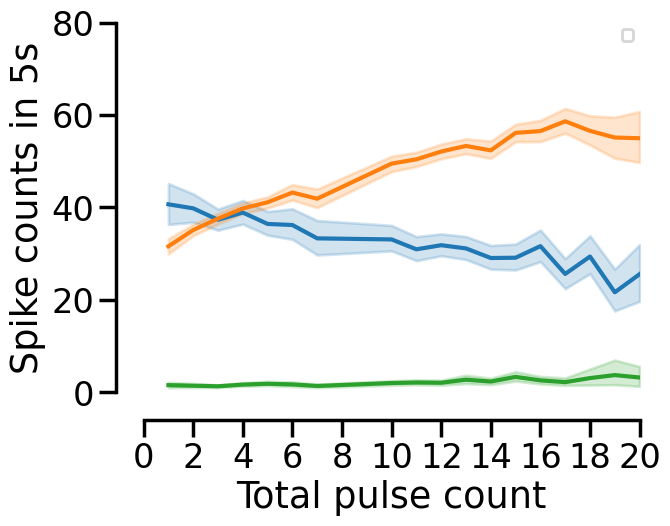

In [ ]:
sns.lineplot(data=final_df.loc[(final_df['Total_pulse']<8) | (final_df['Total_pulse']>9)], 
             x='Total_pulse', y='Spike Counts', hue='Tag', legend=False)

plt.legend(fontsize=10)
plt.xticks(np.linspace(0,20,11))
plt.xlim(0,20)
plt.ylim(0,80)
plt.ylabel('Spike counts in 5s')
plt.xlabel('Total pulse count')
sns.despine(offset=20)


#plt.savefig('Avg_spike_counts_3_groups.svg', format='svg', transparent=True)



In [ ]:
cols = [
    "Animal", "Session", "Trial",
    "Total_pulse", "Cell", "Tag", "Spike Counts"  # etc.
]


with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    final_df[cols].to_excel(writer, sheet_name="Figure_4B", index=False)

([<matplotlib.patches.Wedge at 0x7fc091bf3220>,
 [Text(-1.0721331604854492, -0.24602944170867475, 'Above8Higher'),
  Text(1.0899406746718283, 0.14842279372091152, 'Below8Higher'),
  Text(0.09911688575812486, 1.0955253730323231, 'Equal')],
 [Text(-0.5847999057193358, -0.13419787729564076, '57.2%'),
  Text(0.5945130952755426, 0.08095788748413356, '39.9%'),
  Text(0.054063755868068095, 0.5975592943812671, '2.9%')])

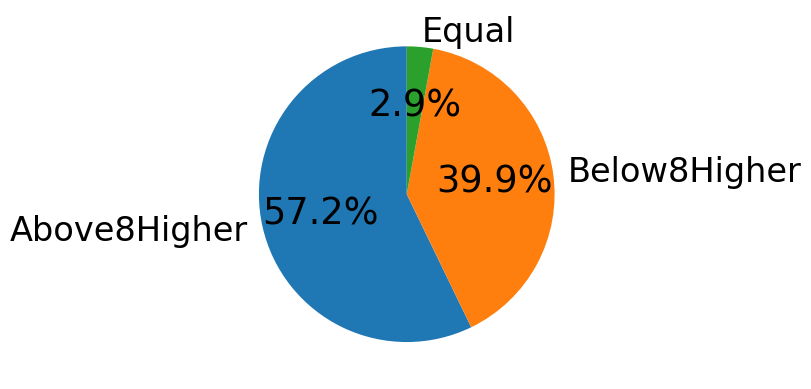

In [ ]:
savepath = './figures/test/svg/'
counts = tags['Tag'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
#plt.savefig(savepath+'pie_chart_neurons_firing.svg', format='svg', transparent=True, bbox_inches='tight')

In [ ]:
counts

Tag
Above8Higher    219
Below8Higher    153
Equal            11
Name: count, dtype: int64

In [ ]:
enh_act_cells_df = final_df.loc[final_df['Tag']=='Above8Higher']
inh_act_cells_df = final_df.loc[final_df['Tag']=='Below8Higher']
equal_cells_df = final_df.loc[final_df['Tag']=='Equal']


# Step 1: Expand the DataFrame
expanded_df_enh = enh_act_cells_df.explode('FR_normalized').reset_index(drop=True)
expanded_df_inh = inh_act_cells_df.explode('FR_normalized').reset_index(drop=True)
expanded_df_enh['Index'] = expanded_df_enh.groupby(expanded_df_enh.index // 450).cumcount()
expanded_df_inh['Index'] = expanded_df_inh.groupby(expanded_df_inh.index // 450).cumcount()


expanded_df_enh

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Cell,Spike_times,Firing_rates,FR_normalized,Tag,Pulse_tag,Spike Counts,Index
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,8,0
1,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,8,1
2,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,8,2
3,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,8,3
4,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23999845,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,28,445
23999846,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,28,446
23999847,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,28,447
23999848,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,28,448


In [ ]:
# Select 10 random levels of B for each A
def sample_B(group):
    unique_B = group['Cell'].unique()
    sampled_B = np.random.choice(unique_B, size=min(1, 10), replace=False)
    return group[group['Cell'].isin(sampled_B)]

df_inh_filtered = inh_act_cells_df.groupby('Session', group_keys=False).apply(sample_B)
df_inh_filtered['Cell'].unique()


array([10,  0, 13,  5, 21,  8,  9, 17, 16,  2, 18, 15, 28, 20,  4, 22, 14,
        7,  1, 12,  3, 19])

(0.0, 125.0)

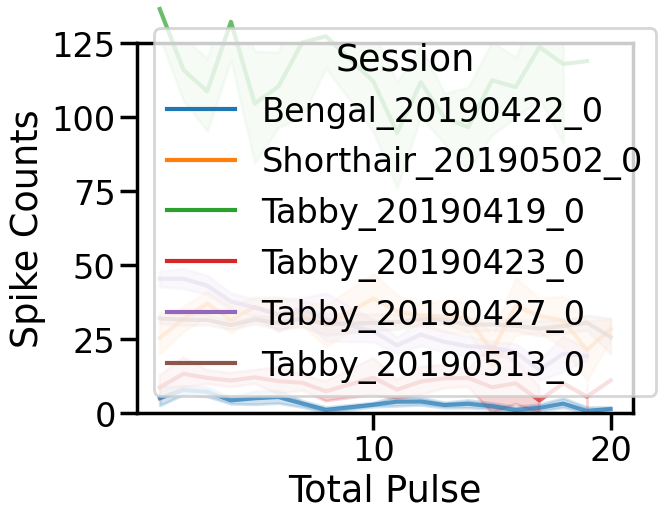

In [ ]:
sns.lineplot(data = inh_act_cells_df.loc[inh_act_cells_df['Cell']==1], x='Total Pulse', y='Spike Counts', alpha=0.7, hue = 'Session', errorbar=('ci'),legend=True, clip_on=False)#, label="Cell")  palette=color_mapping, 
plt.ylim(0,125)

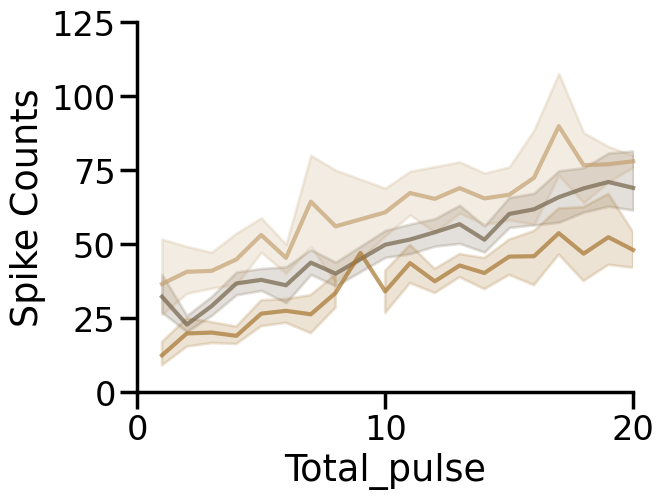

In [ ]:
exp_df_few_1 = enh_act_cells_df.loc[(enh_act_cells_df['Session']=='Bengal_20190503_0') & (enh_act_cells_df['Cell']==6)]
exp_df_few_2 = enh_act_cells_df.loc[(enh_act_cells_df['Session']=='Bengal_20190505_0') & (enh_act_cells_df['Cell']==11)]
exp_df_few_3 = enh_act_cells_df.loc[(enh_act_cells_df['Session']=='Tabby_20190511_0') & (enh_act_cells_df['Cell']==12)]

exp_df_enh_show = pd.concat([exp_df_few_1, exp_df_few_2, exp_df_few_3])

color_mapping = {6:'#73634A', 11:'#C3A171', 12:'#A6752D'} #A6752D' #C3A171

#Bengal_20190503_0_Cell_6
#Bengal_20190505_0_Cell_11
#Tabby_20190511_0_Cell_12
sns.lineplot(data = exp_df_enh_show, x='Total_pulse', y='Spike Counts', alpha=0.7, hue = 'Cell', errorbar=('ci', 95), palette=color_mapping, legend=False, clip_on=False)#, label="Cell")
plt.xticks([0,10,20])#ax.legend()
plt.yticks(np.linspace(0,125,6))#[0,10,20])
plt.xlim(0,20)
sns.despine()
#plt.savefig('exc_neurons_APCx_vs_pulse_count_sample.svg', format='svg')
plt.show()


In [ ]:
exp_df_enh_show

,Animal,Session,Date,Trial,Total_pulse,High_trial,High_choice,Correct,Cell,Spike_times,Firing_rates,FR_normalized,Tag,Pulse_tag,Spike Counts
19290,Bengal,Bengal_20190503_0,20190503,0,15,1,1,1,6,"[0.729, 0.8215333333333333, 0.8264666666666667...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",Above8Higher,D,72
19291,Bengal,Bengal_20190503_0,20190503,1,4,0,0,1,6,"[0.644, 0.6877666666666666, 0.7136666666666667...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.43198386...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.03427914...",Above8Higher,A,65
19292,Bengal,Bengal_20190503_0,20190503,2,1,0,0,1,6,"[0.522, 0.8143666666666667, 0.8715666666666667...","[11.421638919150702, 14.208096982840285, 15.28...","[1.71098351424218, 1.6918532107049966, 1.55676...",Above8Higher,A,59
19293,Bengal,Bengal_20190503_0,20190503,3,4,0,0,1,6,"[0.6048666666666667, 0.9078666666666667, 0.927...","[0.0, 0.0, 0.0, 0.43198386882480433, 1.1126823...","[0.0, 0.0, 0.0, 0.03984914106859274, 0.0965826...",Above8Higher,A,56
19294,Bengal,Bengal_20190503_0,20190503,4,14,1,1,1,6,"[0.5036, 0.5183666666666666, 0.549033333333333...","[34.25826073637543, 37.42665455135298, 37.0513...","[5.131953457946217, 4.456642275536832, 3.77475...",Above8Higher,D,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86048,Tabby,Tabby_20190511_0,20190511,295,2,0,0,1,12,"[0.5030333333333333, 0.5060666666666667, 0.539...","[38.49907739174911, 39.83783288483128, 37.0513...","[9.21589217252701, 7.813479434304282, 6.326637...",Above8Higher,A,30
86049,Tabby,Tabby_20190511_0,20190511,296,4,0,0,1,12,"[0.5947, 0.5981333333333333, 0.6084, 0.6300666...","[0.0, 0.0, 0.8639677376496087, 2.6573484840184...","[0.0, 0.0, 0.1475251686101189, 0.4120778522711...",Above8Higher,A,23
86050,Tabby,Tabby_20190511_0,20190511,297,13,1,0,0,12,"[0.5826666666666667, 0.7518666666666667, 0.754...","[0.0, 0.43198386882480433, 1.1126823075968013,...","[0.0, 0.08472592082936799, 0.18999395218654166...",Above8Higher,D,36
86051,Tabby,Tabby_20190511_0,20190511,298,13,1,1,1,12,"[0.5806333333333333, 0.7533666666666666, 0.757...","[0.0, 0.43198386882480433, 1.1126823075968013,...","[0.0, 0.08472592082936799, 0.18999395218654166...",Above8Higher,D,43


In [ ]:
cols = [
    "Animal", "Session", "Trial",
    "Total_pulse", "Cell", "Tag", "Spike Counts"  # etc.
]


with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    exp_df_enh_show.to_excel(writer, sheet_name="Figure_4B_example1", index=False)

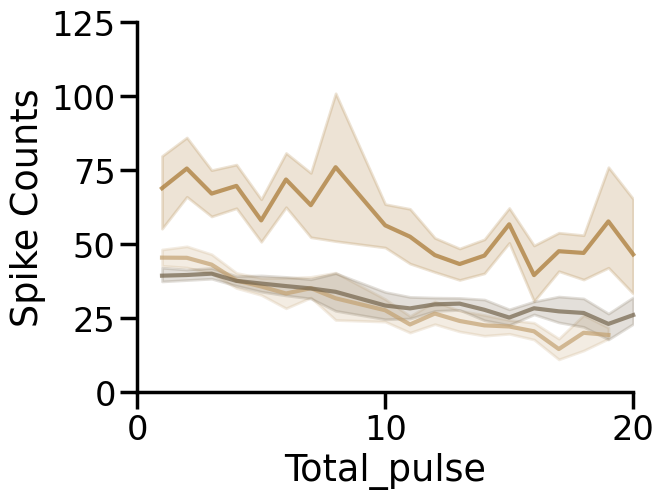

In [ ]:
inh_df_few_1 = inh_act_cells_df.loc[(inh_act_cells_df['Session']=='Tabby_20190513_0') & (inh_act_cells_df['Cell']==11)]
inh_df_few_2 = inh_act_cells_df.loc[(inh_act_cells_df['Session']=='Tabby_20190427_0') & (inh_act_cells_df['Cell']==1)]
inh_df_few_3 = inh_act_cells_df.loc[(inh_act_cells_df['Session']=='Bengal_20190513_0') & (inh_act_cells_df['Cell']==6)]

exp_df_inh_show = pd.concat([inh_df_few_1, inh_df_few_2, inh_df_few_3])

color_mapping = {11:'#73634A', 1:'#C3A171', 6:'#A6752D'} #A6752D' #C3A171

#Bengal_20190503_0_Cell_6
#Bengal_20190505_0_Cell_11
#Tabby_20190511_0_Cell_12
sns.lineplot(data = exp_df_inh_show, x='Total_pulse', y='Spike Counts', alpha=0.7, hue = 'Cell', errorbar=('ci', 95), palette=color_mapping, legend=False, clip_on=False)#, label="Cell")
plt.xticks([0,10,20])#ax.legend()
plt.yticks(np.linspace(0,125,6))#[0,10,20])
plt.xlim(0,20)
sns.despine()
#plt.savefig('inh_neurons_APCx_vs_pulse_count_sample.svg', format='svg')
plt.show()

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    exp_df_inh_show.to_excel(writer, sheet_name="Figure_4B_example2", index=False)

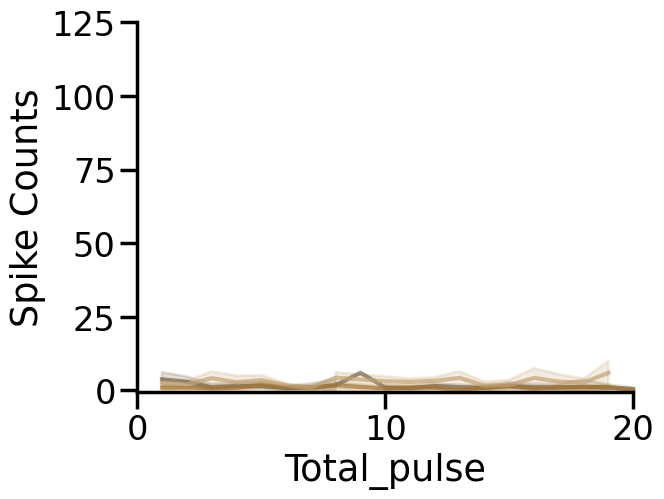

In [ ]:
equal_df_few_1 = equal_cells_df.loc[(equal_cells_df['Session']=='Tabby_20190511_0') & (equal_cells_df['Cell']==1)]
equal_df_few_2 = equal_cells_df.loc[(equal_cells_df['Session']=='Bengal_20190507_0') & (equal_cells_df['Cell']==14)]
equal_df_few_3 = equal_cells_df.loc[(equal_cells_df['Session']=='Shorthair_20190503_0') & (equal_cells_df['Cell']==5)]

equal_df_show = pd.concat([equal_df_few_1, equal_df_few_2, equal_df_few_3])

color_mapping = {1:'#73634A', 14:'#C3A171', 5:'#A6752D'} #A6752D' #C3A171

#Bengal_20190503_0_Cell_6
#Bengal_20190505_0_Cell_11
#Tabby_20190511_0_Cell_12
sns.lineplot(data = equal_df_show, x='Total_pulse', y='Spike Counts', alpha=0.7, hue = 'Cell', errorbar=('ci', 95), palette=color_mapping, legend=False, clip_on=False)#, label="Cell")
plt.xticks([0,10,20])#ax.legend()
plt.yticks(np.linspace(0,125,6))#[0,10,20])
plt.xlim(0,20)
sns.despine()
plt.savefig('equal_neurons_APCx_vs_pulse_count_sample.svg', format='svg')
plt.show()

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    equal_df_show.to_excel(writer, sheet_name="Figure_4B_example3", index=False)

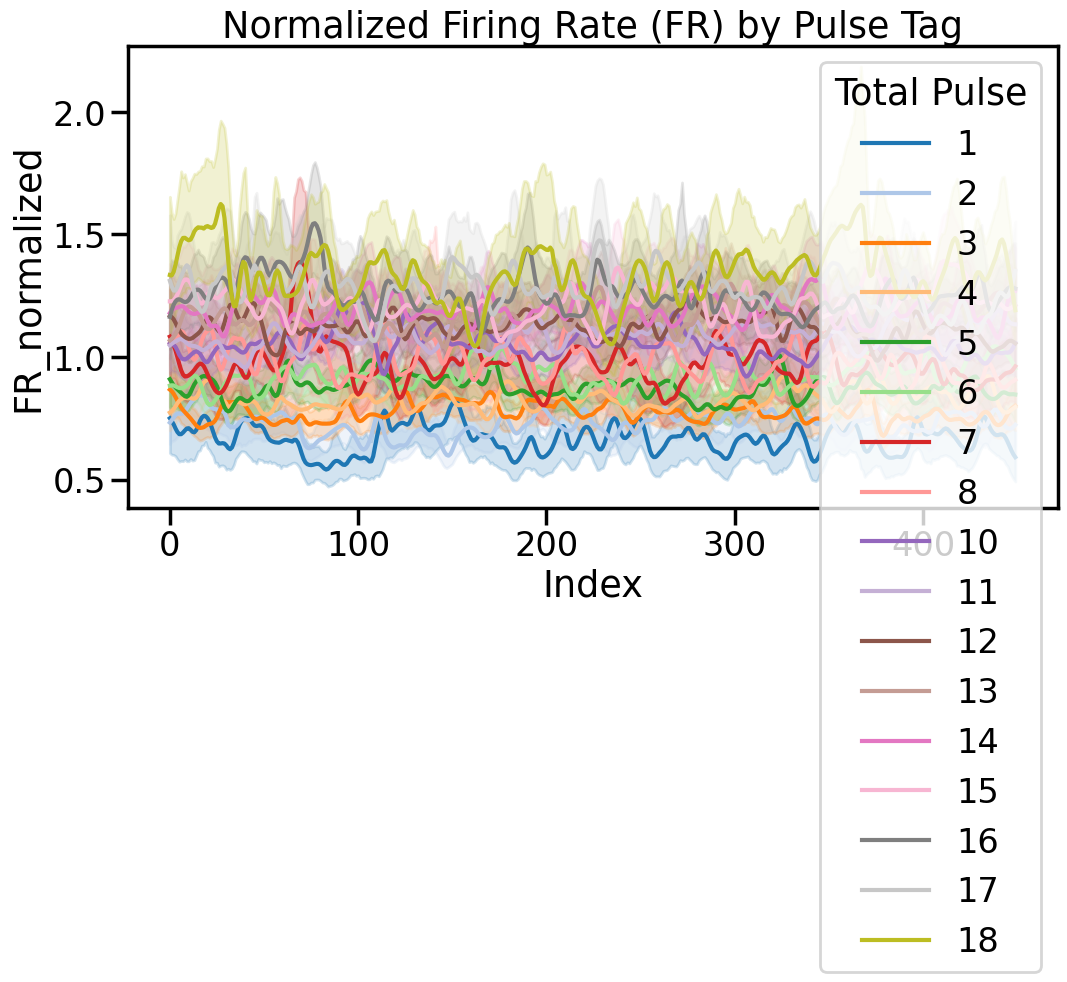

In [ ]:
# Ensure the `FR_normalized` column is numeric
expanded_df_enh['FR_normalized'] = expanded_df_enh['FR_normalized'].astype(float)


# Step 3: Plot the Data
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=expanded_df_enh.loc[(expanded_df_enh['Total Pulse']<19) & (expanded_df_enh['Total Pulse']!=9)],
    x='Index',
    y='FR_normalized',
    hue='Total Pulse',
    palette='tab20'
)
plt.title('Normalized Firing Rate (FR) by Pulse Tag')
plt.xlabel('Index')
plt.ylabel('FR_normalized')
#plt.legend(title='Total Pulse')
plt.show()

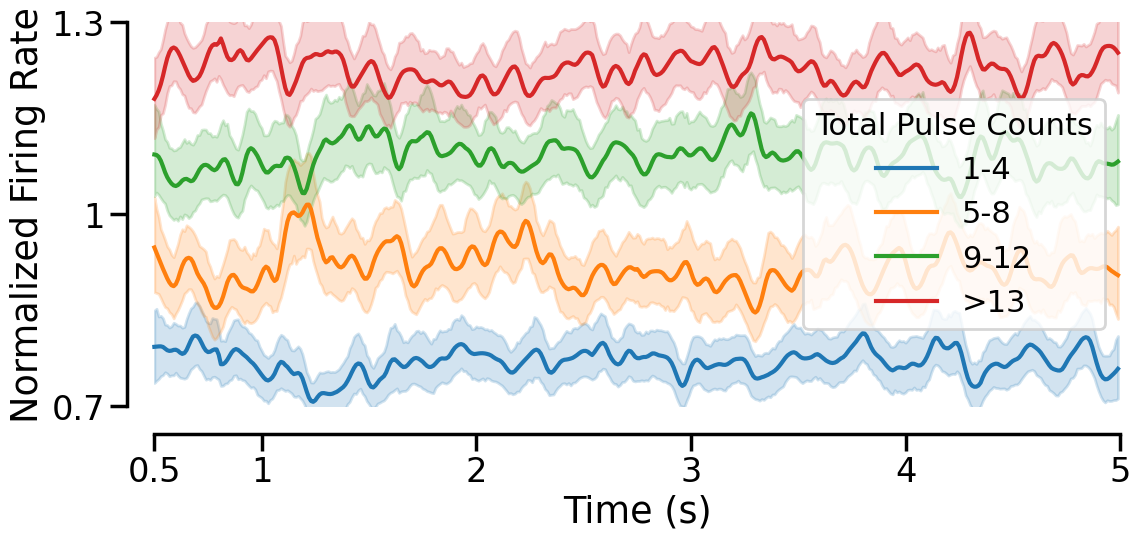

In [ ]:

# Ensure the `FR_normalized` column is numeric
expanded_df_enh['FR_normalized'] = expanded_df_enh['FR_normalized'].astype(float)

# Step 3: Plot the Data
plt.figure(figsize=(12, 6))
ax2 = sns.lineplot(
    data=expanded_df_enh.sort_values(by='Pulse_tag'),
    x='Index',
    y='FR_normalized',
    hue='Pulse_tag',
    palette='tab10', clip_on=False
)
handles, labels = ax2.get_legend_handles_labels()  # Get current handles and labels
custom_labels = ['1-4', '5-8', '9-12', '>13']  # New custom labels
ax2.legend(handles=handles, labels=custom_labels, title='Total Pulse Counts', title_fontsize='small', fontsize='small')  # Update legend

#plt.title('Normalized Firing Rate (FR) by Pulse Tag')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Firing Rate')
ax2.set_xticks(ticks=[0, 50, 150, 250, 350, 450], labels=[0.5, 1, 2, 3, 4,5])
ax2.set_yticks(ticks=[0.7, 1, 1.3], labels=[0.7, 1, 1.3])

sns.despine(offset=20)
plt.xlim(0,450)
plt.ylim(0.7,1.3)
plt.tight_layout()
#plt.savefig(savepath+'above_8_neurons_firing.svg', format='svg', transparent=True, bbox_inches='tight')

plt.show()


In [ ]:

# 95% z-score
z = 1.96

summary_exc = (
    expanded_df_enh
    .groupby(['Pulse_tag', 'Index'])['FR_normalized']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)

# Standard error of the mean
summary_exc['sem'] = summary_exc['std'] / np.sqrt(summary_exc['count'])

# CI bounds
summary_exc['ci_lower'] = summary_exc['mean'] - z * summary_exc['sem']
summary_exc['ci_upper'] = summary_exc['mean'] + z * summary_exc['sem']

# Optionally drop count/std/sem if you don't need them
summary_exc = summary_exc.drop(columns=['count', 'std', 'sem'])
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    summary_exc.to_excel(writer, sheet_name="Figure_4C", index=False)

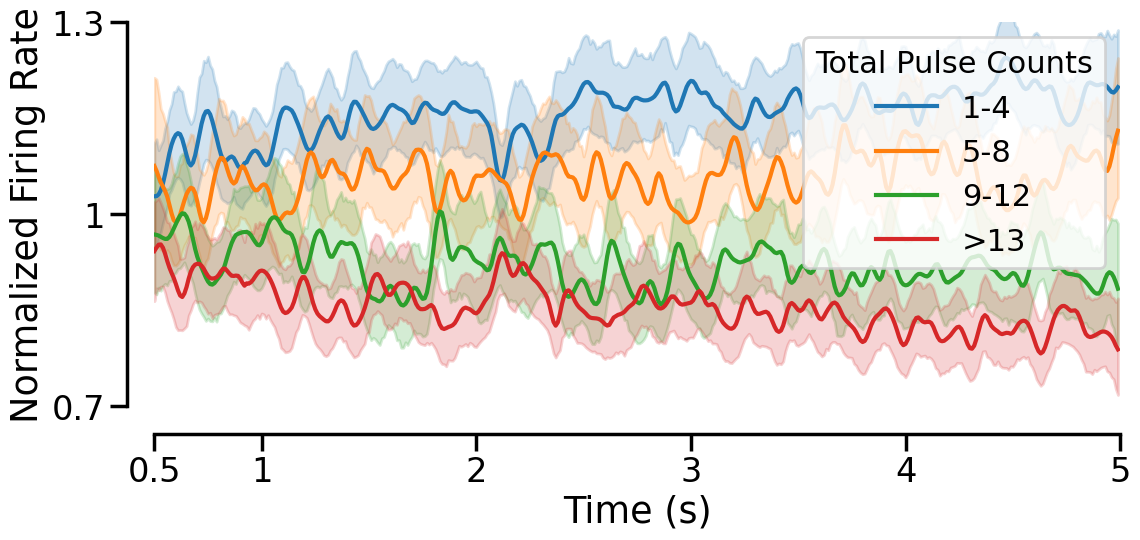

In [ ]:
# Ensure the `FR_normalized` column is numeric
expanded_df_inh['FR_normalized'] = expanded_df_inh['FR_normalized'].astype(float)

# Step 3: Plot the Data
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=expanded_df_inh.sort_values(by='Pulse_tag'), #.loc[expanded_df_inh['Session']=='Bengal_20190419_0']
    x='Index',
    y='FR_normalized',
    hue='Pulse_tag',
    palette='tab10',
    legend='full'
)
handles, labels = ax.get_legend_handles_labels()  # Get current handles and labels
custom_labels = ['1-4', '5-8', '9-12', '>13']  # New custom labels
ax.legend(handles=handles, labels=custom_labels, title='Total Pulse Counts', title_fontsize='small', fontsize='small')  # Update legend

#plt.title('Normalized Firing Rate (FR) by Pulse Tag')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Firing Rate')
ax.set_xticks(ticks=[0, 50, 150, 250, 350, 450], labels=[0.5, 1, 2, 3, 4,5])
ax.set_yticks(ticks=[0.7, 1, 1.3], labels=[0.7, 1, 1.3])

sns.despine(offset=20)
plt.xlim(0,450)
plt.ylim(0.7,1.3)
plt.tight_layout()
plt.savefig(savepath+'below_8_neurons_firing.svg', format='svg', transparent=True, bbox_inches='tight')
plt.show()


In [ ]:
# 95% z-score
z = 1.96

summary_inh = (
    expanded_df_enh
    .groupby(['Pulse_tag', 'Index'])['FR_normalized']
    .agg(['mean', 'count', 'std'])
    .reset_index()
)

# Standard error of the mean
summary_inh['sem'] = summary_inh['std'] / np.sqrt(summary_inh['count'])

# CI bounds
summary_inh['ci_lower'] = summary_inh['mean'] - z * summary_inh['sem']
summary_inh['ci_upper'] = summary_inh['mean'] + z * summary_inh['sem']

# Optionally drop count/std/sem if you don't need them
summary_inh = summary_inh.drop(columns=['count', 'std', 'sem'])
with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    summary_inh.to_excel(writer, sheet_name="Figure_4C2", index=False)

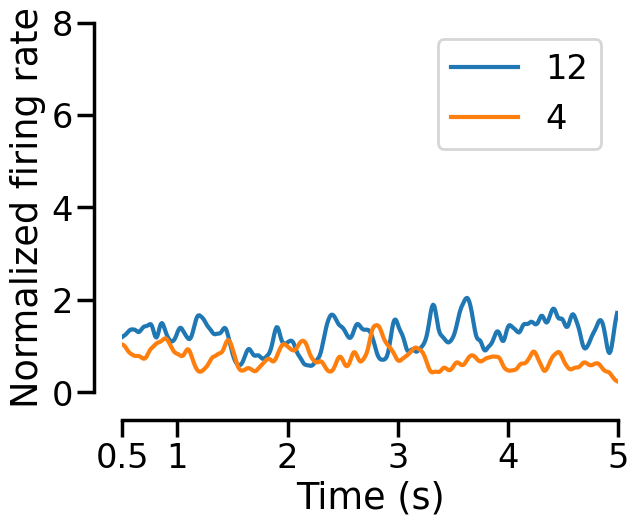

In [ ]:
new_df = result_df.loc[(result_df['Session']=='Shorthair_20190427_0') & (result_df['Cell']==7)]# & (result_df['Total Pulse']==4) | (result_df['Total Pulse']==12)]
new_df_2 = (new_df.groupby(['Total_pulse'])['FR_normalized']
    .apply(mean_across_lists)
    .reset_index())

new_df_2

plt.plot(new_df_2['FR_normalized'][12])#, legend='16 pulses')
plt.plot(new_df_2['FR_normalized'][4])#, legend = '4 pulses')
plt.ylabel('Normalized firing rate')
plt.xlabel('Time (s)')
plt.legend(['12', '4'])
plt.xlim(0,450)
plt.ylim(0,8)
plt.xticks(ticks=[0, 50, 150, 250, 350, 450], labels=[0.5, 1, 2, 3, 4,5])
sns.despine(offset=20)



In [ ]:

the_cells = expanded_df_inh.loc[expanded_df_inh['Session']=='Tabby_20190511_0']['Cell'].unique()
print(the_cells)

# for i in the_cells:
#     print(i)
#     xx_df = result_df.loc[(result_df['Session']=='Bengal_20190509_0') & (result_df['Cell']==i)]
#     print(len(xx_df.loc[xx_df['Total Pulse']==4]['Trial'].unique()), len(xx_df.loc[xx_df['Total Pulse']==12]['Trial'].unique()))

[3 4]


array([  2,  13,  32,  36,  48,  49,  57,  61,  62,  63,  64,  79,  81,
        95, 101, 103, 116, 117, 132, 138, 140, 144, 148, 160, 166, 177,
       186, 192, 194, 200, 221, 236, 247, 251, 257, 261, 276, 293, 306,
       322, 323, 327, 331, 332, 334])

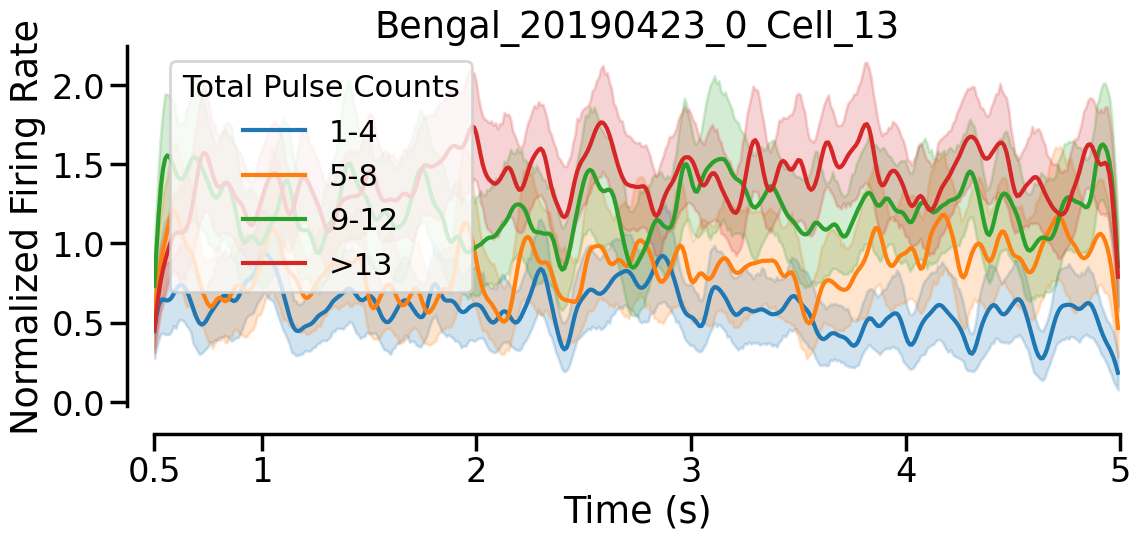

In [ ]:
# Ensure the `FR_normalized` column is numeric
expanded_df_inh['FR_normalized'] = expanded_df_inh['FR_normalized'].astype(float)

# Step 3: Plot the Data
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=expanded_df_enh.loc[(expanded_df_enh['Session']=='Bengal_20190426_0') & (expanded_df_enh['Cell']==7)].sort_values(by='Pulse_tag'), #.loc[expanded_df_inh['Session']=='Bengal_20190419_0']
    x='Index',
    y='FR_normalized',
    hue='Pulse_tag',
    palette='tab10',
    legend='full'
)
handles, labels = ax.get_legend_handles_labels()  # Get current handles and labels
custom_labels = ['1-4', '5-8', '9-12', '>13']  # New custom labels
ax.legend(handles=handles, labels=custom_labels, title='Total Pulse Counts', title_fontsize='small', fontsize='small')  # Update legend

plt.title('Bengal_20190423_0_Cell_13')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Firing Rate')
ax.set_xticks(ticks=[0, 50, 150, 250, 350, 450], labels=[0.5, 1, 2, 3, 4,5])
sns.despine(offset=20)
plt.xlim(0,450)
#plt.ylim(0,2.0)
plt.tight_layout()
plt.show()

In [ ]:
#np.random(seed=101)
trials_to_test = np.random.choice(expanded_df_enh.loc[expanded_df_enh['Total Pulse']==4]['Trial'].unique(), 10)

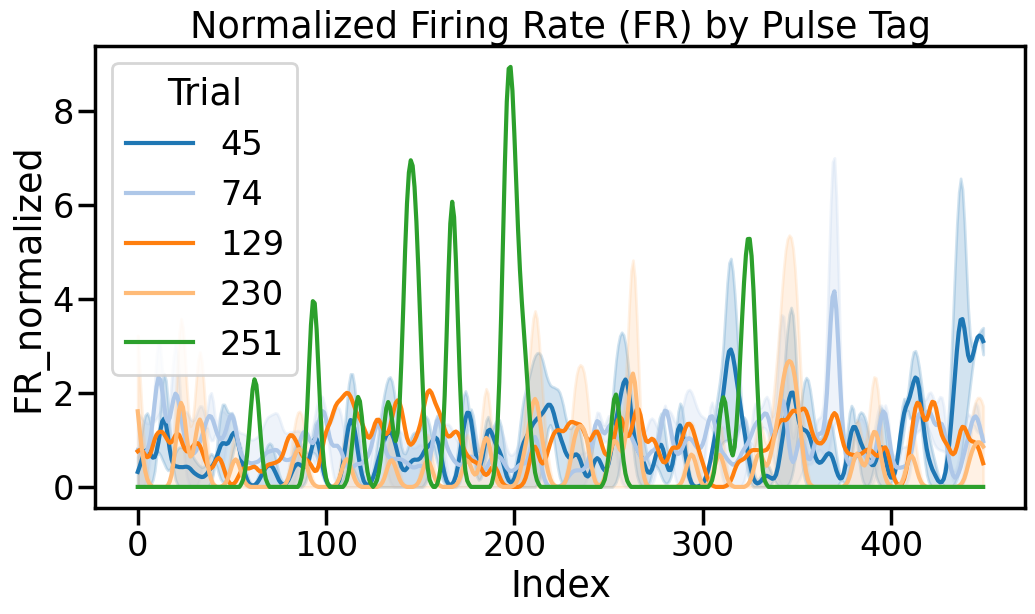

In [ ]:
# Ensure the `FR_normalized` column is numeric
expanded_df_enh['FR_normalized'] = expanded_df_enh['FR_normalized'].astype(float)


# Step 3: Plot the Data
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=expanded_df_enh.loc[(expanded_df_enh['Total Pulse']==4) & (expanded_df_enh['Trial'].isin(trials_to_test)) & (expanded_df_enh['Cell']==0)],# & (expanded_df_enh['Total Pulse']!=9)],
    x='Index',
    y='FR_normalized',
    hue='Trial',
    palette='tab20'
)
plt.title('Normalized Firing Rate (FR) by Pulse Tag')
plt.xlabel('Index')
plt.ylabel('FR_normalized')
#plt.legend(title='Total Pulse')
plt.show()

In [ ]:
expanded_df_enh

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Cell,Spike times,Firing_rates,FR_normalized,Tag,Pulse_tag,Index
0,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,0
1,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,1
2,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,2
3,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,3
4,Bengal,Bengal_20190419_0,20190419,0,5,0,1,0,3,"[0.7808666666666667, 1.3553666666666666, 1.394...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23999845,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,445
23999846,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,446
23999847,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,447
23999848,Tabby,Tabby_20190514_0,20190514,335,8,0,0,1,14,"[0.7501333333333333, 1.0475333333333334, 1.118...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.0,Above8Higher,B,448


In [ ]:
test_df_x = expanded_df_enh.loc[(expanded_df_enh['Session']=='Bengal_20190502_0') & (expanded_df_enh['Total Pulse']==12)]
test_df_x

,Animal,Session,Date,Trial,Total Pulse,High Trial,High Choice,Correct,Cell,Spike times,Firing_rates,FR_normalized,Tag,Pulse_tag,Index
4431150,Bengal,Bengal_20190502_0,20190502,4,12,1,1,1,0,"[1.0032333333333334, 1.0233, 1.043433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,Above8Higher,C,0
4431151,Bengal,Bengal_20190502_0,20190502,4,12,1,1,1,0,"[1.0032333333333334, 1.0233, 1.043433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,Above8Higher,C,1
4431152,Bengal,Bengal_20190502_0,20190502,4,12,1,1,1,0,"[1.0032333333333334, 1.0233, 1.043433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,Above8Higher,C,2
4431153,Bengal,Bengal_20190502_0,20190502,4,12,1,1,1,0,"[1.0032333333333334, 1.0233, 1.043433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,Above8Higher,C,3
4431154,Bengal,Bengal_20190502_0,20190502,4,12,1,1,1,0,"[1.0032333333333334, 1.0233, 1.043433333333333...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,Above8Higher,C,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5146645,Bengal,Bengal_20190502_0,20190502,209,12,1,1,1,12,"[0.5184333333333333, 0.6829, 0.702366666666666...","[14.208096982840285, 15.280519823236421, 14.20...",0.904796,Above8Higher,C,445
5146646,Bengal,Bengal_20190502_0,20190502,209,12,1,1,1,12,"[0.5184333333333333, 0.6829, 0.702366666666666...","[14.208096982840285, 15.280519823236421, 14.20...",0.801161,Above8Higher,C,446
5146647,Bengal,Bengal_20190502_0,20190502,209,12,1,1,1,12,"[0.5184333333333333, 0.6829, 0.702366666666666...","[14.208096982840285, 15.280519823236421, 14.20...",0.682485,Above8Higher,C,447
5146648,Bengal,Bengal_20190502_0,20190502,209,12,1,1,1,12,"[0.5184333333333333, 0.6829, 0.702366666666666...","[14.208096982840285, 15.280519823236421, 14.20...",0.551498,Above8Higher,C,448


In [ ]:
expanded_df_enh['Session'].unique()

array(['Bengal_20190419_0', 'Bengal_20190422_0', 'Bengal_20190423_0',
       'Bengal_20190426_0', 'Bengal_20190427_0', 'Bengal_20190430_0',
       'Bengal_20190501_0', 'Bengal_20190502_0', 'Bengal_20190503_0',
       'Bengal_20190504_0', 'Bengal_20190505_0', 'Bengal_20190507_0',
       'Bengal_20190508_0', 'Bengal_20190509_0', 'Bengal_20190510_0',
       'Bengal_20190511_0', 'Bengal_20190512_0', 'Bengal_20190513_0',
       'Shorthair_20190419_0', 'Shorthair_20190422_0',
       'Shorthair_20190423_0', 'Shorthair_20190427_0',
       'Shorthair_20190430_0', 'Shorthair_20190501_0',
       'Shorthair_20190502_0', 'Shorthair_20190503_0',
       'Shorthair_20190504_0', 'Shorthair_20190505_0',
       'Shorthair_20190507_0', 'Tabby_20190419_0', 'Tabby_20190423_0',
       'Tabby_20190427_0', 'Tabby_20190430_0', 'Tabby_20190501_0',
       'Tabby_20190503_0', 'Tabby_20190504_0', 'Tabby_20190505_0',
       'Tabby_20190510_0', 'Tabby_20190511_0', 'Tabby_20190512_0',
       'Tabby_20190513_0', 'Tabby

In [ ]:
test_df_x['Trial'].unique()

array([  4,   8,   9,  41,  51,  56,  73, 100, 103, 107, 112, 129, 152,
       169, 189, 205, 209])

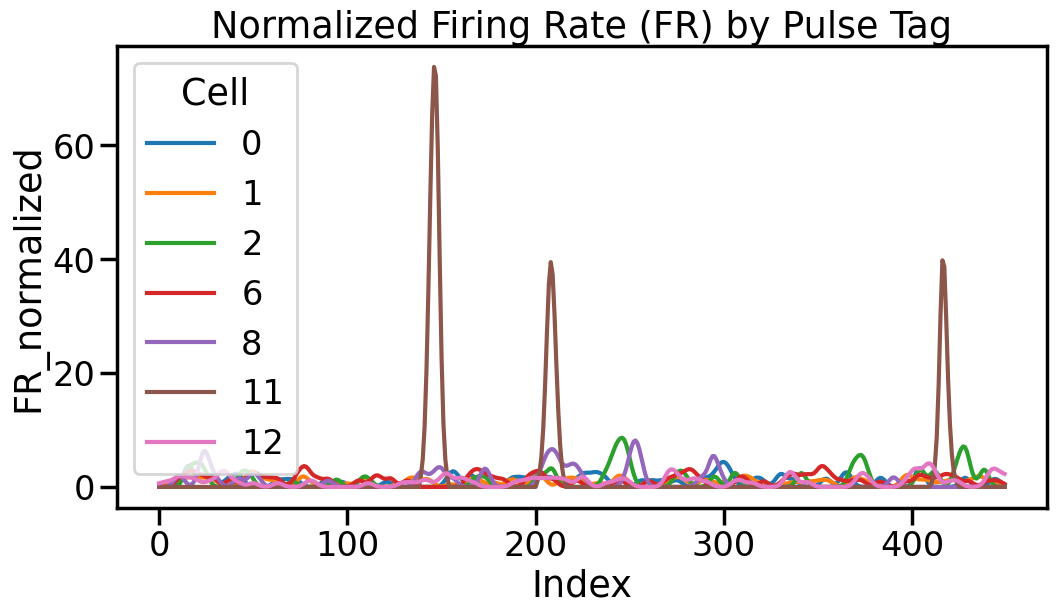

In [ ]:
# Ensure the `FR_normalized` column is numeric
test_df_x['FR_normalized'] = test_df_x['FR_normalized'].astype(float)


# Step 3: Plot the Data
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=test_df_x.loc[test_df_x['Trial']==41],#) & (expanded_df_enh['Trial'].isin(trials_to_test)) & (expanded_df_enh['Cell']==0)],# & (expanded_df_enh['Total Pulse']!=9)],
    x='Index',
    y='FR_normalized',
    hue='Cell',
    palette='tab10'
)
plt.title('Normalized Firing Rate (FR) by Pulse Tag')
plt.xlabel('Index')
plt.ylabel('FR_normalized')
#plt.legend(title='Total Pulse')
plt.show()

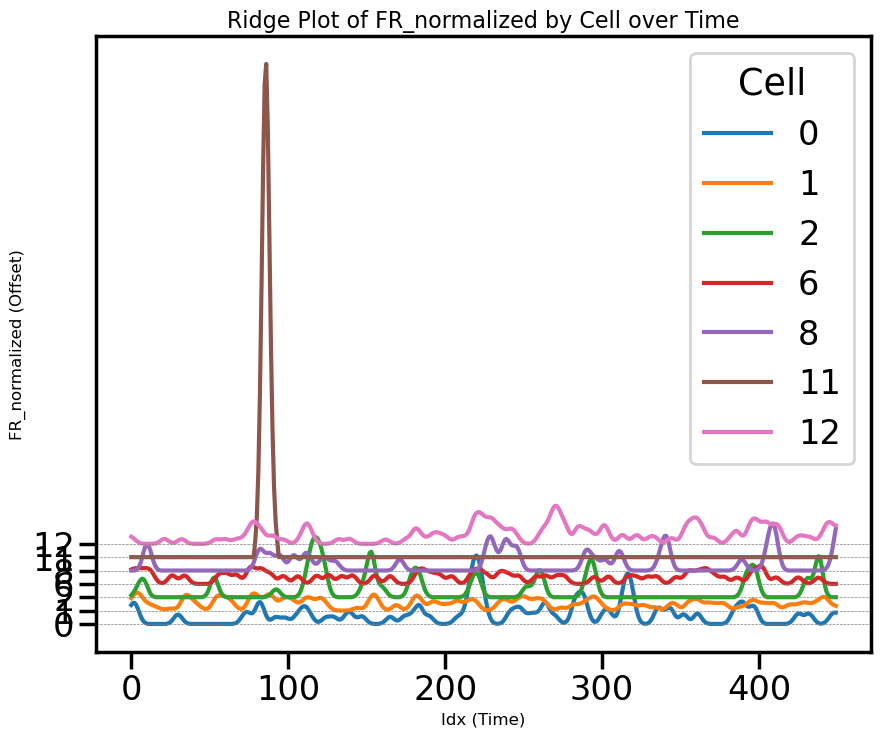

In [ ]:
# Get unique Cells
cells = test_df_x['Cell'].unique()

# Create Ridge Plot
plt.figure(figsize=(10, 8))
offset = 2  # Vertical offset between ridges
for i, cell in enumerate(cells):
    subset = test_df_x.loc[(test_df_x['Cell'] == cell) & (test_df_x['Trial']==169)]
    plt.plot(
        subset['Index'],
        subset['FR_normalized'] + i * offset,  # Offset each ridge
        label=cell
    )

    # Add a baseline for each ridge
    plt.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')

# Formatting
plt.title('Ridge Plot of FR_normalized by Cell over Time', fontsize=16)
plt.xlabel('Idx (Time)', fontsize=12)
plt.ylabel('FR_normalized (Offset)', fontsize=12)
plt.yticks(ticks=[i * offset for i in range(len(cells))], labels=cells)
plt.legend(title='Cell', loc='upper right')
plt.show()

In [ ]:
expanded_df_enh.loc[expanded_df_enh['Session']=='Tabby_20190514_0']['Cell'].unique()

array([ 1,  2,  7,  8, 11, 12, 14])

In [ ]:
example_df = expanded_df_enh.loc[(expanded_df_enh['Session']=='Shorthair_20190427_0') & (expanded_df_enh['Cell']==7)]
new_example_df_4 = example_df.loc[example_df['Total_pulse']==4]# | (example_df['Total Pulse']==16)]
new_example_df_4['Trial'].unique()

# Get unique Cells
example_trials_4 = new_example_df_4['Trial'].unique()
#sel_trials = example_trials[0:5]
#print(sel_trials[2])


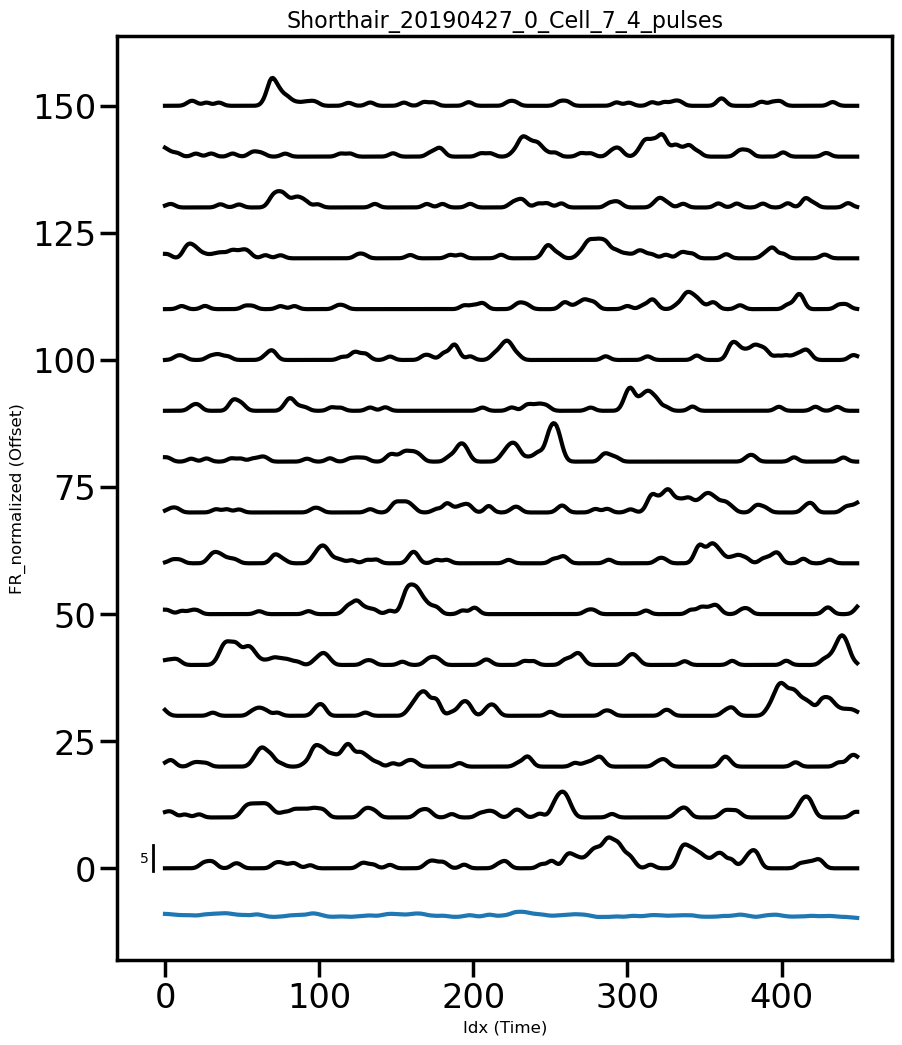

In [ ]:
# Create Ridge Plot
plt.figure(figsize=(10, 12))
offset = 10  # Vertical offset between ridges
for i, trial in enumerate(example_trials_4):
    subset = new_example_df_4.loc[new_example_df_4['Trial'] == trial]#) & test_df_x['Trial']==111]
    plt.plot(
        subset['Index'],
        subset['FR_normalized'] + i * offset,  # Offset each ridge
        #label=f'{trial} (Offset: {i * offset:.1f})',
        color='k'
    )
  

    # Add a baseline for each ridge
    #plt.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')  # Add baseline
    # Annotate y-axis scale for reference
#     if i == 0:  # Annotate first ridge scale
#         for y_value in [-1, 0, 1]:  # Example reference points
#             plt.text(
#                 50, y_value + i * offset, f'{y_value:.1f}',
#                 color='black', fontsize=10
#             )
scale_bar_length = 5  # Define the length of the scale bar in data units
scale_bar_x = -8      # Position of the scale bar on the x-axis
scale_bar_y = -.5    # Position of the scale bar on the y-axis

plt.plot(
    [scale_bar_x, scale_bar_x],  # Vertical line
    [scale_bar_y, scale_bar_y + scale_bar_length],
    color='black', linewidth=2
)
plt.text(
    scale_bar_x -8, scale_bar_y + scale_bar_length / 2,
    f'{scale_bar_length}', va='center', fontsize=10
)

# Y-Axis Ticks Reflecting Offset and Scale
# plt.yticks(
#     ticks=[i * offset for i in range(len(cells))],
#     labels=cells
# )
lowest_ridge_y = -offset
plt.plot(range(len(new_df_2['FR_normalized'][4])), new_df_2['FR_normalized'][4] + lowest_ridge_y)

#plt.plot(new_df_2['FR_normalized'][4])#, legend = '4 pulses')

# Formatting
plt.title('Shorthair_20190427_0_Cell_7_4_pulses', fontsize=16)
plt.xlabel('Idx (Time)', fontsize=12)
plt.ylabel('FR_normalized (Offset)', fontsize=12)
#plt.yticks(ticks=[i * offset for i in range(len(example_trials_4))], labels=example_trials_4)
#plt.legend(title='Cell', loc='upper right')
#plt.savefig('Ridge_plot_low_pulses.svg', format='svg', transparent='true', bbox_inches='tight')
plt.show()

In [ ]:
cols = [
    "Animal", "Session", "Trial",
    "Total_pulse", "Cell", "Tag", "FR_normalized", "Spike Counts"  # etc.
]

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    new_example_df_4[cols].to_excel(writer, sheet_name="Figure_4A_4pulses", index=False)

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    new_df_2.to_excel(writer, sheet_name="Figure_4A_4pulses_mean", index=False)

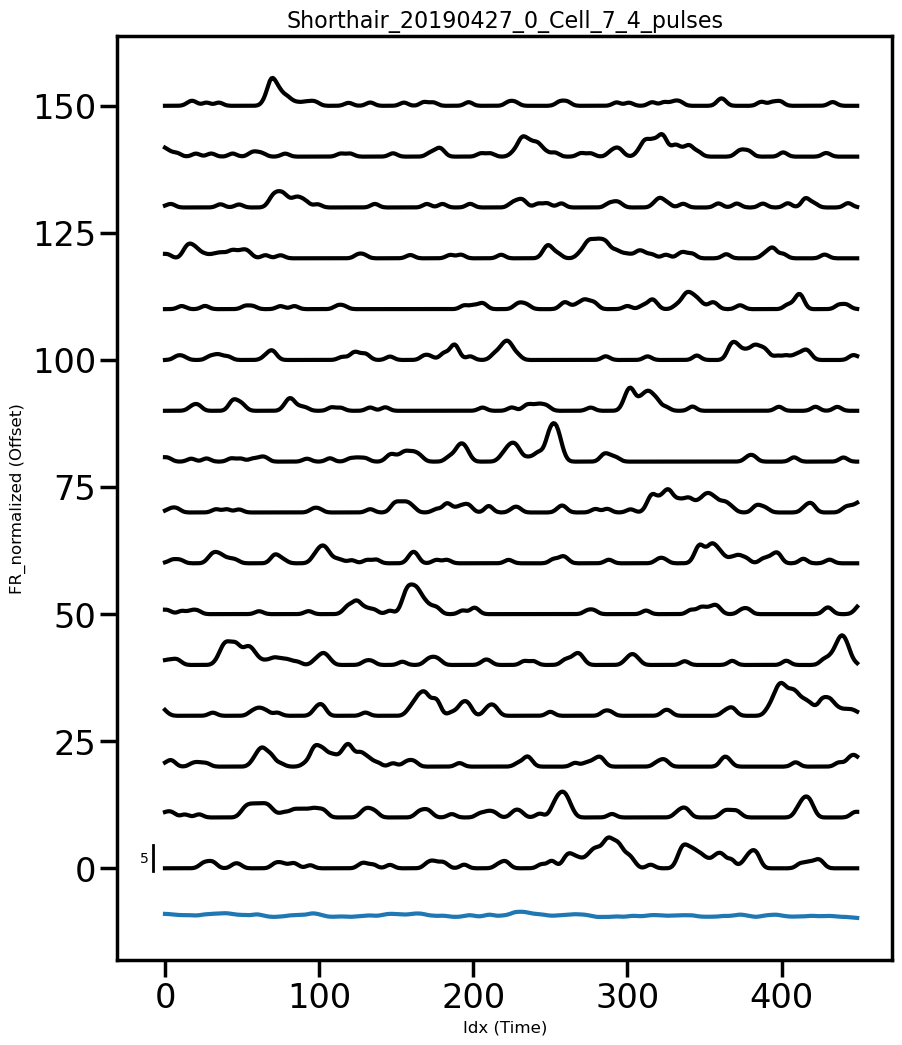

In [ ]:

# Create Ridge Plot
plt.figure(figsize=(10, 12))
offset = 10  # Vertical offset between ridges
for i, trial in enumerate(example_trials_4):
    subset = new_example_df_4.loc[new_example_df_4['Trial'] == trial]#) & test_df_x['Trial']==111]
    plt.plot(
        subset['Index'],
        subset['FR_normalized'] + i * offset,  # Offset each ridge
        #label=f'{trial} (Offset: {i * offset:.1f})',
        color='k'
    )
  

    # Add a baseline for each ridge
    #plt.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')  # Add baseline
    # Annotate y-axis scale for reference
#     if i == 0:  # Annotate first ridge scale
#         for y_value in [-1, 0, 1]:  # Example reference points
#             plt.text(
#                 50, y_value + i * offset, f'{y_value:.1f}',
#                 color='black', fontsize=10
#             )
scale_bar_length = 5  # Define the length of the scale bar in data units
scale_bar_x = -8      # Position of the scale bar on the x-axis
scale_bar_y = -.5    # Position of the scale bar on the y-axis

plt.plot(
    [scale_bar_x, scale_bar_x],  # Vertical line
    [scale_bar_y, scale_bar_y + scale_bar_length],
    color='black', linewidth=2
)
plt.text(
    scale_bar_x -8, scale_bar_y + scale_bar_length / 2,
    f'{scale_bar_length}', va='center', fontsize=10
)

# Y-Axis Ticks Reflecting Offset and Scale
# plt.yticks(
#     ticks=[i * offset for i in range(len(cells))],
#     labels=cells
# )
lowest_ridge_y = -offset
plt.plot(range(len(new_df_2['FR_normalized'][4])), new_df_2['FR_normalized'][4] + lowest_ridge_y)

#plt.plot(new_df_2['FR_normalized'][4])#, legend = '4 pulses')

# Formatting
plt.title('Shorthair_20190427_0_Cell_7_4_pulses', fontsize=16)
plt.xlabel('Idx (Time)', fontsize=12)
plt.ylabel('FR_normalized (Offset)', fontsize=12)
#plt.yticks(ticks=[i * offset for i in range(len(example_trials_4))], labels=example_trials_4)
#plt.legend(title='Cell', loc='upper right')
plt.savefig('Ridge_plot_low_pulses.svg', format='svg', transparent='true', bbox_inches='tight')
plt.show()

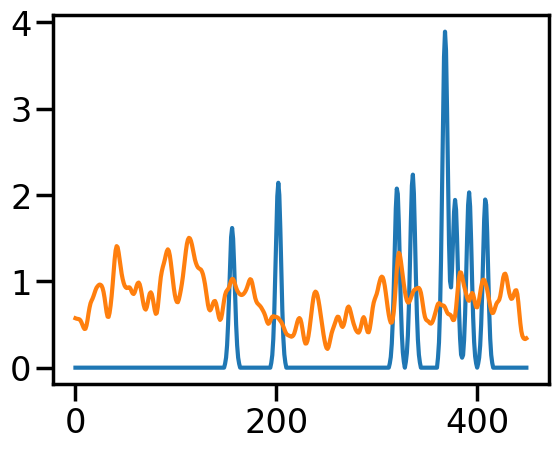

In [ ]:
trial_1 = new_example_df_4.loc[new_example_df_4['Trial']==1]

plt.plot(trial_1['Index'], trial_1['FR_normalized'])
plt.plot(new_df_2['FR_normalized'][4])#, legend = '4 pulses')


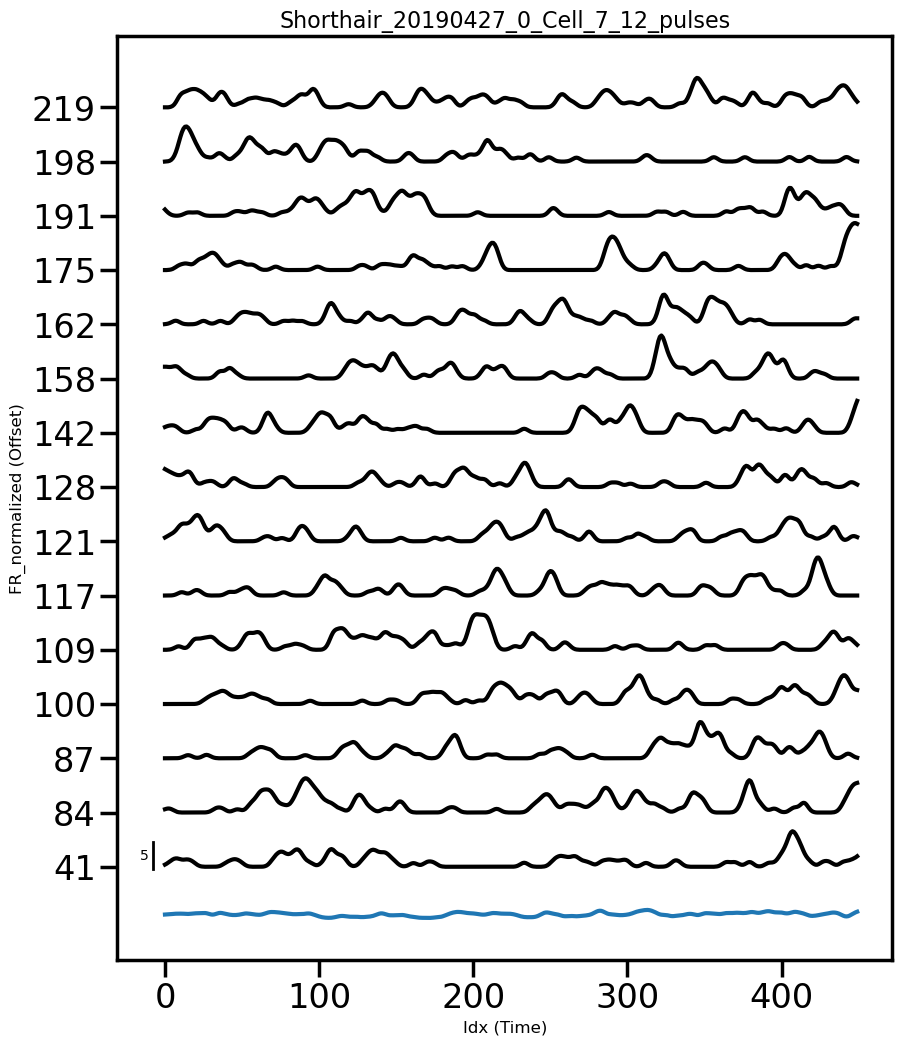

In [ ]:
#example_df = expanded_df_enh.loc[(expanded_df_enh['Session']=='Tabby_20190514_0') & (expanded_df_enh['Cell']==14)]
new_example_df_12 = example_df.loc[example_df['Total_pulse']==12]# | (example_df['Total Pulse']==16)]
new_example_df_12['Trial'].unique()

plt.figure(figsize=(10, 12))

# Get unique Cells
example_trials_12 = new_example_df_12['Trial'].unique()
#sel_trials = example_trials[0:5]
#print(sel_trials[2])
# Create Ridge Plot
#plt.figure(figsize=(10, 8))
offset = 10  # Vertical offset between ridges
for i, trial in enumerate(example_trials_12):
    subset = new_example_df_12.loc[new_example_df_12['Trial'] == trial]#) & test_df_x['Trial']==111]
    plt.plot(
        subset['Index'],
        subset['FR_normalized'] + i * offset,  # Offset each ridge
        label=f'{trial} (Offset: {i * offset:.1f})',
        color='k'
    )
  

    # Add a baseline for each ridge
    #plt.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')  # Add baseline
    # Annotate y-axis scale for reference
#     if i == 0:  # Annotate first ridge scale
#         for y_value in [-1, 0, 1]:  # Example reference points
#             plt.text(
#                 50, y_value + i * offset, f'{y_value:.1f}',
#                 color='black', fontsize=10
#             )
scale_bar_length = 5  # Define the length of the scale bar in data units
scale_bar_x = -8      # Position of the scale bar on the x-axis
scale_bar_y = -.5    # Position of the scale bar on the y-axis

plt.plot(
    [scale_bar_x, scale_bar_x],  # Vertical line
    [scale_bar_y, scale_bar_y + scale_bar_length],
    color='black', linewidth=2
)
plt.text(
    scale_bar_x -8, scale_bar_y + scale_bar_length / 2,
    f'{scale_bar_length}', va='center', fontsize=10
)

# Y-Axis Ticks Reflecting Offset and Scale
# plt.yticks(
#     ticks=[i * offset for i in range(len(cells))],
#     labels=cells
# )
lowest_ridge_y = -offset
plt.plot(range(len(new_df_2['FR_normalized'][12])), new_df_2['FR_normalized'][12] + lowest_ridge_y)

#plt.plot(new_df_2['FR_normalized'][4])#, legend = '4 pulses')

# Formatting
plt.title('Shorthair_20190427_0_Cell_7_12_pulses', fontsize=16)
plt.xlabel('Idx (Time)', fontsize=12)
plt.ylabel('FR_normalized (Offset)', fontsize=12)
plt.yticks(ticks=[i * offset for i in range(len(example_trials_12))], labels=example_trials_12)
#plt.legend(title='Cell', loc='upper right')
#plt.savefig('Ridge_plot_high_pulses.svg', format='svg', transparent='true', bbox_inches='tight')

plt.show()

In [ ]:
cols = [
    "Animal", "Session", "Trial",
    "Total_pulse", "Cell", "Tag", "FR_normalized", "Spike Counts"  # etc.
]

with pd.ExcelWriter(
    "source_data_all_figs.xlsx",
    engine="openpyxl",
    mode="a",                 # append to existing file q
    if_sheet_exists="new"     # avoid overwriting an existing sheet
) as writer:
    
    new_example_df_12[cols].to_excel(writer, sheet_name="Figure_4A_12pulses", index=False)

In [ ]:
new_df_2['FR_normalized'][4]

array([1.03004771, 1.02137338, 1.00194915, 0.97229068, 0.93572932,
       0.89918326, 0.86865862, 0.84574286, 0.82734888, 0.81210242,
       0.79792214, 0.78733561, 0.78298362, 0.78395997, 0.78418639,
       0.78168426, 0.77161566, 0.75773788, 0.74069446, 0.72669794,
       0.72342979, 0.736157  , 0.7667276 , 0.81219499, 0.86025715,
       0.90531882, 0.93763879, 0.96185411, 0.98360744, 1.00654159,
       1.03108239, 1.05290311, 1.06738323, 1.07803803, 1.08629419,
       1.09745897, 1.11549035, 1.13720423, 1.15647612, 1.16436177,
       1.15371424, 1.1288387 , 1.09079769, 1.04726822, 1.001269  ,
       0.95451445, 0.91276819, 0.87813298, 0.85472372, 0.8394541 ,
       0.82859801, 0.81784897, 0.80322324, 0.78734573, 0.78021559,
       0.78787815, 0.8145568 , 0.8554772 , 0.89715742, 0.9250936 ,
       0.9254274 , 0.89353526, 0.83901435, 0.77033675, 0.70053598,
       0.63276957, 0.57164744, 0.52141796, 0.48215461, 0.45606258,
       0.44354778, 0.44198598, 0.45199191, 0.46880592, 0.48919

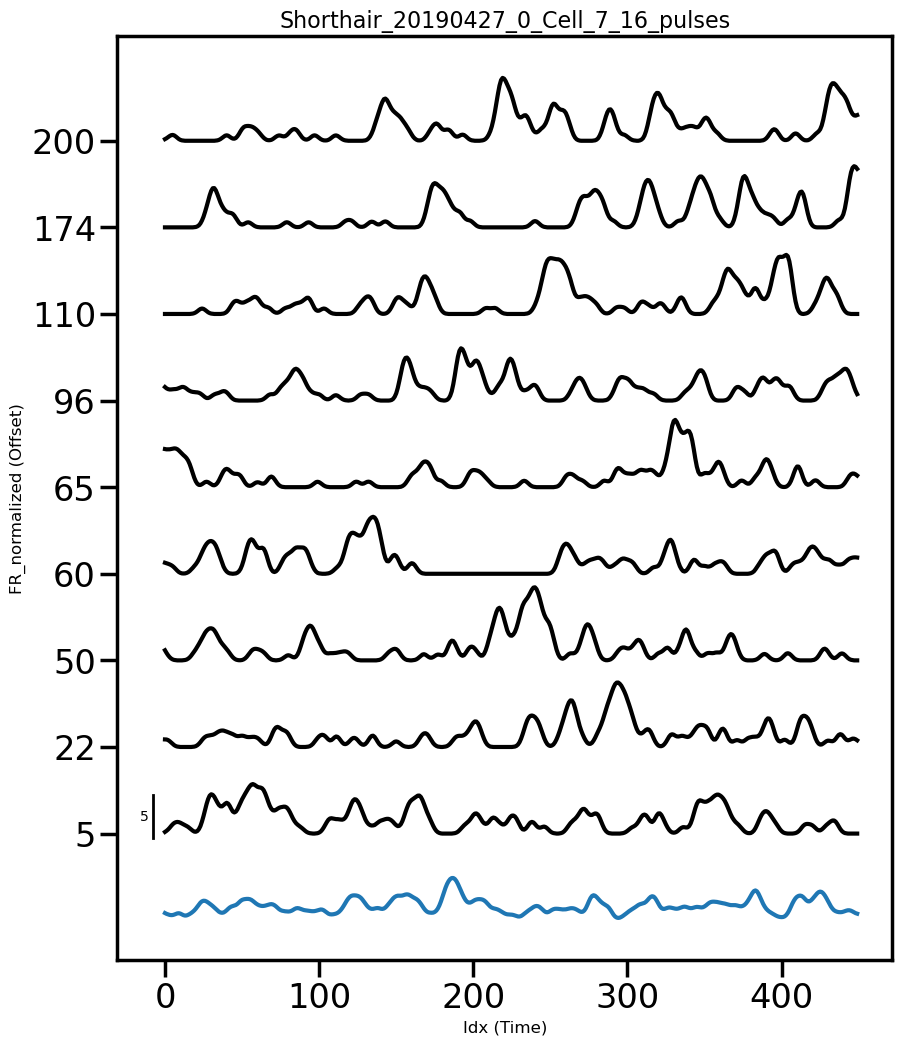

In [ ]:
#example_df = expanded_df_enh.loc[(expanded_df_enh['Session']=='Tabby_20190514_0') & (expanded_df_enh['Cell']==14)]
new_example_df_16 = example_df.loc[example_df['Total Pulse']==16]# | (example_df['Total Pulse']==16)]
new_example_df_16['Trial'].unique()

plt.figure(figsize=(10, 12))

# Get unique Cells
example_trials_16 = new_example_df_16['Trial'].unique()
#sel_trials = example_trials[0:5]
#print(sel_trials[2])
# Create Ridge Plot
#plt.figure(figsize=(10, 8))
offset = 10  # Vertical offset between ridges
for i, trial in enumerate(example_trials_16):
    subset = new_example_df_16.loc[new_example_df_16['Trial'] == trial]#) & test_df_x['Trial']==111]
    plt.plot(
        subset['Index'],
        subset['FR_normalized'] + i * offset,  # Offset each ridge
        label=f'{trial} (Offset: {i * offset:.1f})',
        color='k'
    )
  

    # Add a baseline for each ridge
    #plt.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')  # Add baseline
    # Annotate y-axis scale for reference
#     if i == 0:  # Annotate first ridge scale
#         for y_value in [-1, 0, 1]:  # Example reference points
#             plt.text(
#                 50, y_value + i * offset, f'{y_value:.1f}',
#                 color='black', fontsize=10
#             )
scale_bar_length = 5  # Define the length of the scale bar in data units
scale_bar_x = -8      # Position of the scale bar on the x-axis
scale_bar_y = -.5    # Position of the scale bar on the y-axis

plt.plot(
    [scale_bar_x, scale_bar_x],  # Vertical line
    [scale_bar_y, scale_bar_y + scale_bar_length],
    color='black', linewidth=2
)
plt.text(
    scale_bar_x -8, scale_bar_y + scale_bar_length / 2,
    f'{scale_bar_length}', va='center', fontsize=10
)

# Y-Axis Ticks Reflecting Offset and Scale
plt.yticks(
    ticks=[i * offset for i in range(len(cells))],
    labels=cells
)
lowest_ridge_y = -offset
plt.plot(range(len(new_df_2['FR_normalized'][1])), new_df_2['FR_normalized'][16] + lowest_ridge_y)

#plt.plot(new_df_2['FR_normalized'][4])#, legend = '4 pulses')

# Formatting
plt.title('Shorthair_20190427_0_Cell_7_16_pulses', fontsize=16)
plt.xlabel('Idx (Time)', fontsize=12)
plt.ylabel('FR_normalized (Offset)', fontsize=12)
plt.yticks(ticks=[i * offset for i in range(len(example_trials_16))], labels=example_trials_16)
#plt.legend(title='Cell', loc='upper right')
plt.savefig('Ridge_plot_high_pulses.svg', format='svg', transparent='true', bbox_inches='tight')

plt.show()

[ 22  32  33  38  40  49  54  70  76  99 100 105 108 128 136 172 190 197
 201 215 216 224 229 235 265 271 275 276 296]
[  6  14  23  24  30  46  56  69  73  75  77 115 116 134 142 147 154 160
 163 186 188 214 238 267 268 284 287]


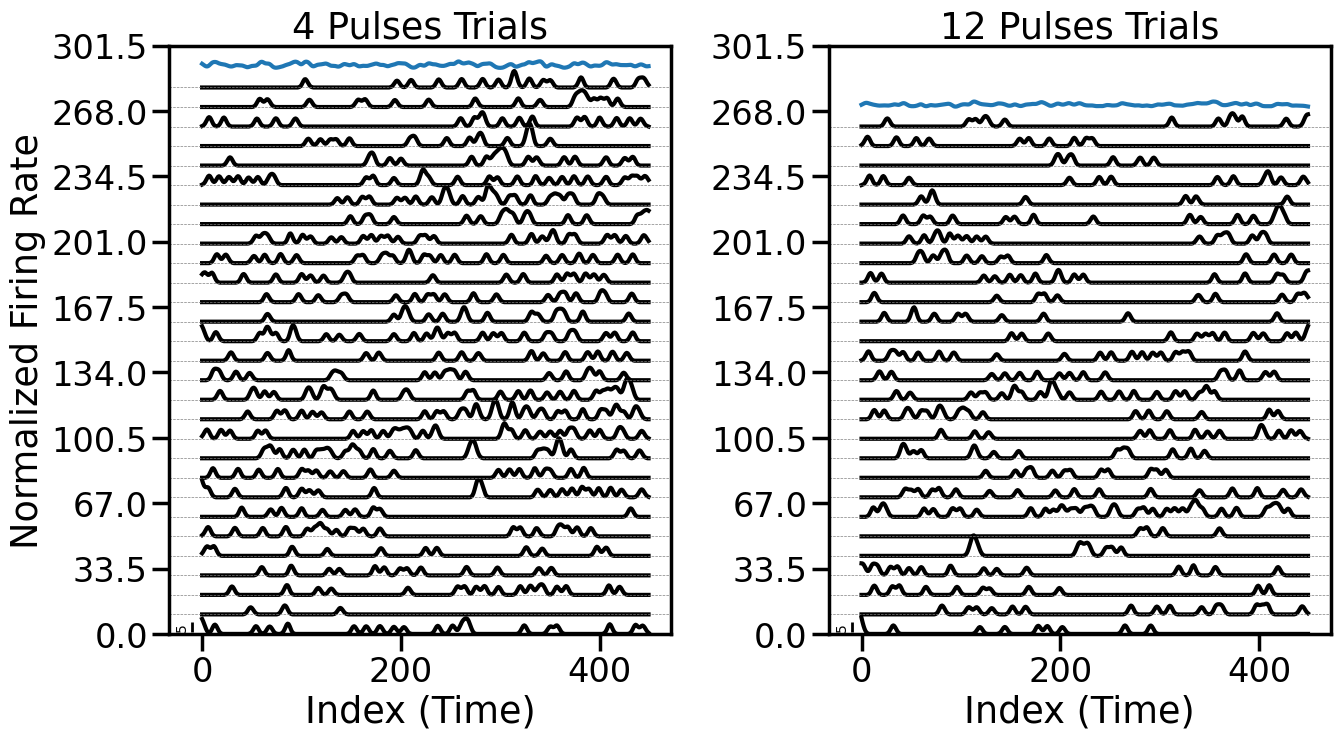

Y-axis scales are confirmed to be identical.


In [ ]:
# Let's start again
from matplotlib.gridspec import GridSpec


example_df = expanded_df_inh.loc[(expanded_df_inh['Session']=='Tabby_20190511_0') & (expanded_df_inh['Cell']==3)]

new_example_df_4 = example_df.loc[example_df['Total Pulse']==4]# | (example_df['Total Pulse']==16)]
example_trials_4 = new_example_df_4['Trial'].unique()
print(example_trials_4)

new_example_df_12 = example_df.loc[example_df['Total Pulse']==12]# | (example_df['Total Pulse']==16)]
example_trials_12 = new_example_df_12['Trial'].unique()
print(example_trials_12)

# Fixed offset and calculate y-limits
offset = 10  # Vertical spacing
y_min = min(new_example_df_4['FR_normalized'].min(), new_example_df_12['FR_normalized'].min())
y_max = max(new_example_df_4['FR_normalized'].max(), new_example_df_12['FR_normalized'].max())

# Create Figure and GridSpec for Side-by-Side Plots
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1])


# Left Plot
ax1 = fig.add_subplot(gs[0])
for i, trial in enumerate(example_trials_4):
    subset = new_example_df_4[new_example_df_4['Trial'] == trial]
    ax1.plot(
        subset['Index'],
        subset['FR_normalized'] + i * offset,
        label=trial,
        color='k'
    )
    ax1.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')

ax1.plot(range(len(new_df_2['FR_normalized'][4])), new_df_2['FR_normalized'][4] + (i+1) * offset)


ax1.set_title('4 Pulses Trials')
ax1.set_xlabel('Index (Time)')
ax1.set_ylabel('Normalized Firing Rate')
#ax1.legend(title='Trial', loc='upper right')

# Right Plot
ax2 = fig.add_subplot(gs[1])
for i, trial in enumerate(example_trials_12):
    subset_12 = new_example_df_12[new_example_df_12['Trial'] == trial]
    ax2.plot(
        subset_12['Index'],
        subset_12['FR_normalized'] + i * offset,
        label=trial, #cell
        color='k'
    )
    ax2.axhline(y=i * offset, color='gray', linewidth=0.5, linestyle='--')

ax2.plot(range(len(new_df_2['FR_normalized'][12])), new_df_2['FR_normalized'][12] + (i+1) * offset)


ax2.set_title('12 Pulses Trials')
ax2.set_xlabel('Index (Time)')
#ax2.legend(title='Trial', loc='upper right')

# Ensure Shared Y-Axis Scale
ax1.set_ylim(y_min, y_max + len(example_trials_4)+1 * offset)
ax2.set_ylim(y_min, y_max + len(example_trials_12)+1 * offset)

# Add y-ticks explicitly for visual confirmation
y_ticks = np.linspace(y_min, y_max + max(len(example_trials_4), len(example_trials_12)) * offset, num=10)
ax1.set_yticks(y_ticks)
ax2.set_yticks(y_ticks)


# Y-Axis Scale Bar for ax1 (left plot)
scale_bar_length = 5  # Adjust the length of the scale bar
scale_bar_x = -10  # Slightly left of the y-axis
scale_bar_start = 1  # Bottom of the left ridge
scale_bar_end = scale_bar_start + scale_bar_length  # Top of the scale bar

ax1.vlines(
    x=scale_bar_x,
    ymin=scale_bar_start,
    ymax=scale_bar_end,
    color='black',
    linewidth=2
)
ax1.text(
    scale_bar_x - 10,  # Position text slightly to the left
    scale_bar_start + scale_bar_length / 2,
    f"{scale_bar_length}",
    ha='center',
    va='center',
    fontsize=10,
    rotation=90  # Rotate text for the y-axis
)

# Y-Axis Scale Bar for ax2 (right plot)
scale_bar_x = -10   # Slightly right of the y-axis
scale_bar_start = 1  # Bottom of the right ridge
scale_bar_end = scale_bar_start + scale_bar_length

ax2.vlines(
    x=scale_bar_x,
    ymin=scale_bar_start,
    ymax=scale_bar_end,
    color='black',
    linewidth=2
)
ax2.text(
    scale_bar_x - 10,  # Position text slightly to the right
    scale_bar_start + scale_bar_length / 2,
    f"{scale_bar_length}",
    ha='center',
    va='center',
    fontsize=10,
    rotation=90  # Rotate text for the y-axis
)

plt.tight_layout()
plt.savefig('Ridge_plot_both.svg', format='svg', transparent='true', bbox_inches='tight')

plt.show()

# Programmatic check
assert ax1.get_ylim() == ax2.get_ylim(), "Y-axis scales are not the same!"
print("Y-axis scales are confirmed to be identical.")

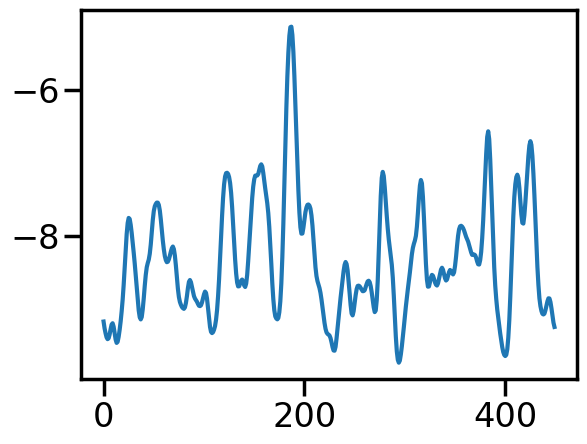

In [ ]:
plt.plot(new_df_2['FR_normalized'][16]-offset)